
# Cyber-Prioritizer: Algoritmo de Priorización Estocástica de Vulnerabilidades

Motor de análisis de riesgo dinámico que combina Cadenas de Markov, inteligencia de amenazas en tiempo real (NVD, EPSS, CISA KEV) y mapeo táctico (MITRE ATT&CK) para optimizar la gestión de vulnerabilidades bajo restricciones de presupuesto operativo.

**Propuesta de Valor: Cyber-Prioritizer no busca reemplazar a NVD, CVSS o EPSS, sino actuar como un complemento orquestador. Toma estas métricas técnicas aisladas y las traduce en decisiones ejecutivas, logrando una reducción directa en costos operativos y horas-hombre al evitar el parcheo innecesario de vulnerabilidades sin probabilidad real de explotación.**

### Creado por **Lukas Benjamín Ahubert Lennon**.

---

## La Metodología

La priorización tradicional basada únicamente en la severidad técnica (CVSS) es estática y asume que todas las vulnerabilidades críticas serán explotadas. Este algoritmo introduce una **metodología estocástica**:

1.  **Probabilidad Real:** Convierte el puntaje EPSS en una tasa diaria de explotación predictiva.
2.  **Cadenas de Markov:** Modela cada activo en una matriz de transición de 4 estados (Seguro, Detectado, Explotado, Mitigado) para proyectar la probabilidad de compromiso en un horizonte de 30 días.
3.  **Riesgo Dinámico:** Pondera la probabilidad matemática de explotación con la criticidad de negocio y la exposición de red del activo.
4.  **Optimización bajo Restricción:** Demuestra matemáticamente cómo asignar *K* parches disponibles para reducir la mayor cantidad de riesgo residual posible.

## Características Principales

*   **Threat Intel Automatizado:** Extracción resiliente desde NIST NVD, FIRST (EPSS) y el catálogo de explotación confirmada de CISA (KEV).
*   **Test A/B Integrado:** Dashboard comparativo que contrasta la curva de mitigación del modelo de Markov vs. el enfoque estático CVSS tradicional.
*   **Generación de Informes Estratégicos:** Exportación automática de la telemetría a reportes ejecutivos en formato Markdown, HTML y DOCX, además de grillas operativas en XLSX para equipos de SecOps.

## Uso Rápido (Demo Interactiva)

Para evaluar el modelo de forma inmediata sin configuración de entorno local:
1. Dirígete a la carpeta `/notebooks`.
2. Abre el archivo `Cyber_Prioritizer.ipynb` en Google Colab o Jupyter.
3. Ejecuta las celdas para procesar la matriz simulada o cargar el inventario CSV de tu propia organización.


## Plantilla de Inventariado

1. Dirígete a la carpeta `/Data`.
2. Abre el archivo `Formulario_Inventario.xlsx`.
3. Dentro del archivo hay parametros que mantienen homogeneidad respecto al llenado e instrucciones.

---

## Licenciamiento Dual y Uso Comercial

Este proyecto de ingeniería opera bajo un modelo de **Licenciamiento Dual**:

### 1. Uso Open Source (AGPLv3)
El código fuente está disponible gratuitamente bajo la licencia GNU AGPLv3. Eres libre de usarlo, modificarlo y distribuirlo para fines académicos, personales o proyectos de código abierto, siempre y cuando cualquier trabajo derivado o servicio de red que lo integre también se libere bajo los términos de la AGPLv3.

### 2. Licencia Comercial Corporativa
Para organizaciones corporativas que requieran integrar este motor de priorización en plataformas propietarias, servicios gestionados de seguridad, o que por normativas internas de *Compliance* no puedan cumplir con los términos de apertura de código de la AGPLv3, se requiere una Licencia Comercial.

Para adquirir una licencia comercial exclusiva, solicitar integración corporativa o consultoría especializada en optimización de procesos y modelamiento de riesgos digitales, las consultas se gestionan a través de **IKUBERT**.

📧 *Contacto:* Contact@ikubert.com

---

# 🗺️ Roadmap y Próximas Mejoras (Versión 2.0)

El desarrollo continuo de **Cyber-Prioritizer** contempla las siguientes optimizaciones para la próxima iteración del framework:

### 1. Escalabilidad para Inventarios Masivos
*   **Objetivo:** Optimizar el pipeline de ingesta y procesamiento (`DataIngestor` y motor de Markov) para soportar y calcular eficientemente inventarios de nivel *Enterprise* superiores a los 1.000 activos simultáneos.
*   **Impacto:** Reducción de tiempos de cómputo en el Test A/B y optimización del uso de memoria al cruzar data con las APIs de inteligencia de amenazas.

### 2. Estabilidad Determinista en el Baseline (CVSS)
*   **Objetivo:** Garantizar la reproducibilidad bit a bit en los empates de severidad del modelo estático.
*   **Detalle Técnico:** Actualmente, la métrica CVSS genera múltiples empates (ej. varios activos con 9.8 o 10.0), los cuales el método `sort_values` de Pandas resuelve de forma no determinista por defecto. Para la v2, las funciones `_curva_mitigacion`, `_hosts_parcheados` y `_ventaja_pct` implementarán el ordenamiento dual: `sort_values(["cvss_score", "riesgo_dinamico"], ascending=False)`.
*   **Impacto:** Asegura que el comparador baseline (Estrategia A) se comporte de manera 100% predecible en cada ejecución del ciclo.

### 3. Optimización de Visualización (Mapa de Riesgo)
*   **Objetivo:** Refactorizar el renderizado del Gráfico 4 (Mapa de Riesgo de Activos) para resolver la superposición de etiquetas de texto (*overplotting*) en clústeres de alta densidad.
*   **Impacto:** Mejora en la legibilidad ejecutiva del dashboard cuando se analizan infraestructuras complejas con riesgo altamente concentrado.

---



In [ ]:
#Librerías
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import json
import time
from datetime import date
import google.generativeai as genai


!pip install -q openpyxl markdown google-generativeai
!apt-get install -y -qq pandoc > /dev/null

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [ ]:
#CONFIGURACIÓN DE APIs (opcionales, ambas gratis)
NVD_API_KEY    = ""   # Para obtener api, siga las instrucciones en el correo https://nvd.nist.gov/developers/request-an-api-key
GEMINI_API_KEY = ""   # Informe redactado por IA: aistudio.google.com/apikey

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
print(f"[OK] NVD key: {'sí' if NVD_API_KEY else 'no (rate-limit 5 req/30s)'} | "
      f"Gemini: {'sí' if GEMINI_API_KEY else 'no (informe con plantillas)'}")

[OK] NVD key: sí | Gemini: sí


In [ ]:
## MÓDULO 1: Generador de inventario simulado
###Empresa mediana: 68 activos IT + IoT + OT, ~51 CVEs reales únicos (todos con respuesta en NVD/EPSS).

## Diseño del dataset (clave para el Test A/B de la tesis):
#- EPSS ALTO (KEV, explotación masiva): el modelo debe priorizarlos.
#- CVSS ALTO pero EPSS BAJO: donde CVSS malgasta parches y Markov no.
#- EPSS BAJO (escalación local): ruido realista de una red corporativa.
#- Flotas: mismo software vulnerable en varios hosts.

def generar_inventario(path: str = "inventario_empresa.csv") -> pd.DataFrame:
    """Genera un inventario simulado de 68 activos (IT+IoT+OT) con CVEs reales."""
    # (host, criticidad_negocio, software, version, cve_id, pilar_nist_csf)
    activos = [
        # ---- PERÍMETRO / RED (EPSS alto: objetivos primarios de ransomware) ----
        ("FW-EDGE-01",    "Alta",  "Cisco IOS XE",             "17.6.3",          "CVE-2023-20198", "Protect"),
        ("VPN-PA-01",     "Alta",  "Palo Alto PAN-OS",         "10.2.3",          "CVE-2024-3400",  "Protect"),
        ("ADC-CTX-01",    "Alta",  "Citrix NetScaler ADC",     "13.1-48.47",      "CVE-2023-4966",  "Protect"),
        ("VPN-PULSE-01",  "Alta",  "Pulse Connect Secure",     "9.0R3",           "CVE-2019-11510", "Protect"),
        ("LB-F5-01",      "Alta",  "F5 BIG-IP",                "16.1.2",          "CVE-2022-1388",  "Protect"),
        ("GW-CTX-02",     "Media", "Citrix ADC Gateway",       "12.1-55.13",      "CVE-2019-19781", "Protect"),
        ("ADC-CTX-02",    "Media", "Citrix ADC",               "13.0-91.12",      "CVE-2023-3519",  "Protect"),
        ("SRV-VPN-01",    "Alta",  "Fortinet FortiOS",         "6.0.4",           "CVE-2018-13379", "Protect"),
        ("SRV-VPN-02",    "Media", "Fortinet FortiOS",         "5.6.10",          "CVE-2018-13379", "Protect"),
        # ---- CONTROLADORES DE DOMINIO / INFRA WINDOWS (EPSS alto) ----
        ("SRV-DC-01",     "Alta",  "Windows Server",           "2019 Datacenter", "CVE-2020-1472",  "Protect"),
        ("SRV-DC-02",     "Alta",  "Windows Server",           "2016 Datacenter", "CVE-2020-1472",  "Protect"),
        ("SRV-FILE-02",   "Alta",  "Windows Server",           "2016 Standard",   "CVE-2017-0144",  "Protect"),
        ("SRV-FILE-04",   "Media", "Windows Server",           "2012 R2",         "CVE-2017-0144",  "Protect"),
        ("SRV-FILE-03",   "Media", "Windows Server",           "2019 Standard",   "CVE-2020-0796",  "Protect"),
        ("SRV-RDP-01",    "Alta",  "Windows Server",           "2008 R2",         "CVE-2019-0708",  "Protect"),
        # ---- CORREO / COLABORACIÓN ----
        ("SRV-MAIL-01",   "Alta",  "Microsoft Exchange",       "2019 CU8",        "CVE-2021-26855", "Respond"),
        ("SRV-MAIL-02",   "Alta",  "Microsoft Exchange",       "2019 CU11",       "CVE-2022-41082", "Respond"),
        ("SRV-WIKI-01",   "Media", "Atlassian Confluence",     "7.13.6",          "CVE-2022-26134", "Identify"),
        ("SRV-WIKI-02",   "Media", "Atlassian Confluence",     "8.5.1",           "CVE-2023-22515", "Identify"),
        # ---- APLICACIONES WEB / ERP (mezcla EPSS alto y contraste) ----
        ("SRV-WEB-01",    "Alta",  "Apache HTTP Server",       "2.4.49",          "CVE-2021-41773", "Identify"),
        ("SRV-WEB-04",    "Media", "Apache HTTP Server",       "2.4.49",          "CVE-2021-41773", "Identify"),
        ("SRV-APP-01",    "Alta",  "Apache Log4j",             "2.14.1",          "CVE-2021-44228", "Detect"),
        ("SRV-APP-02",    "Alta",  "Apache Log4j",             "2.13.3",          "CVE-2021-44228", "Detect"),
        ("SRV-APP-03",    "Media", "Apache Log4j",             "2.12.1",          "CVE-2021-44228", "Detect"),
        ("SRV-WEB-03",    "Alta",  "Apache Struts",            "2.3.31",          "CVE-2017-5638",  "Identify"),
        ("SRV-CMS-01",    "Media", "Drupal",                   "7.57",            "CVE-2018-7600",  "Identify"),
        ("SRV-ERP-01",    "Alta",  "Oracle WebLogic",          "12.2.1.3",        "CVE-2020-14882", "Identify"),
        ("SRV-ERP-02",    "Media", "Oracle WebLogic",          "10.3.6",          "CVE-2019-2725",  "Identify"),
        ("SRV-MFT-01",    "Alta",  "Progress MOVEit Transfer", "2023.0.0",        "CVE-2023-34362", "Protect"),
        ("SRV-IAM-01",    "Alta",  "Zoho ADSelfService Plus",  "6113",            "CVE-2021-40539", "Protect"),
        ("SRV-VC-01",     "Alta",  "VMware vCenter",           "6.7 U3",          "CVE-2021-21972", "Identify"),
        # ---- CVSS ALTO pero EPSS MEDIO/BAJO: el contraste clave de la tesis ----
        ("SRV-WEB-02",    "Alta",  "Apache HTTP Server",       "2.4.55",          "CVE-2023-25690", "Identify"),
        ("SRV-WEB-05",    "Media", "Apache HTTP Server",       "2.4.54",          "CVE-2023-25690", "Identify"),
        ("SRV-DB-01",     "Alta",  "MySQL Server",             "5.7.14",          "CVE-2016-6662",  "Protect"),
        ("SRV-DB-02",     "Alta",  "MySQL Server",             "5.6.30",          "CVE-2016-6662",  "Protect"),
        # ---- WORKSTATIONS POR DEPARTAMENTO ----
        ("WKS-FIN-05",    "Media", "Windows 10",               "1909 Pro",        "CVE-2021-34527", "Protect"),
        ("WKS-FIN-06",    "Media", "Windows 10",               "1909 Pro",        "CVE-2021-34527", "Protect"),
        ("WKS-VTA-03",    "Media", "Windows 10",               "21H2 Pro",        "CVE-2021-34527", "Protect"),
        ("WKS-VTA-04",    "Baja",  "Windows 10",               "20H2 Pro",        "CVE-2021-34527", "Protect"),
        ("WKS-RRHH-01",   "Media", "Microsoft Office",         "2019 Pro",        "CVE-2022-30190", "Detect"),
        ("WKS-RRHH-02",   "Baja",  "Microsoft Office",         "2016 Std",        "CVE-2022-30190", "Detect"),
        # ---- LINUX / EPSS BAJO: escalación local (requiere acceso previo) ----
        ("SRV-LNX-01",    "Media", "Ubuntu Linux Kernel",      "5.13.0",          "CVE-2022-0847",  "Detect"),
        ("SRV-LNX-02",    "Media", "GNU glibc",                "2.35",            "CVE-2023-4911",  "Detect"),
        ("SRV-LNX-03",    "Media", "Linux Kernel",             "5.15.0",          "CVE-2021-33909", "Detect"),
        ("SRV-LNX-04",    "Baja",  "Linux Kernel",             "5.10.0",          "CVE-2022-2588",  "Detect"),
        ("SRV-LNX-05",    "Baja",  "Netfilter Linux Kernel",   "6.3.1",           "CVE-2023-32233", "Detect"),
        ("SRV-DOCKER-01", "Media", "Linux Kernel cgroups",     "5.4.0",           "CVE-2022-0492",  "Detect"),
        ("WKS-ADM-01",    "Media", "Polkit pkexec",            "0.105",           "CVE-2021-4034",  "Respond"),
        ("WKS-DEV-04",    "Baja",  "Polkit pkexec",            "0.113",           "CVE-2021-4034",  "Respond"),
        ("WKS-DEV-02",    "Baja",  "Sudo",                     "1.8.31",          "CVE-2021-3156",  "Recover"),
        ("WKS-DEV-03",    "Baja",  "Sudo",                     "1.9.5p1",         "CVE-2021-3156",  "Recover"),
        ("WKS-TI-01",     "Baja",  "Linux Kernel",             "4.8.0",           "CVE-2016-5195",  "Respond"),
        # ---- LEGADO (deuda técnica realista) ----
        ("SRV-LEGACY-01", "Baja",  "OpenSSL",                  "1.0.1f",          "CVE-2014-0160",  "Recover"),
        ("SRV-LEGACY-02", "Baja",  "OpenSSL",                  "1.0.1e",          "CVE-2014-0160",  "Recover"),
        ("SRV-LEGACY-03", "Media", "Windows Server",           "2008 SP2",        "CVE-2019-0708",  "Recover"),
        # ---- IoT / DISPOSITIVOS (superficie de ataque no tradicional) ----
        ("CAM-EXT-01",    "Media", "Hikvision IP Camera",      "DS-2CD2 5.4.5",   "CVE-2021-36260", "Detect"),
        ("CAM-INT-02",    "Baja",  "Hikvision IP Camera",      "DS-2CD2 5.4.5",   "CVE-2021-36260", "Detect"),
        ("CAM-INT-03",    "Baja",  "Dahua IP Camera",          "IPC-HDW 2.800",   "CVE-2021-33044", "Detect"),
        ("PRN-FIN-01",    "Baja",  "HP LaserJet Enterprise",   "M607 2405129",    "CVE-2021-39238", "Protect"),
        ("PRN-RRHH-02",   "Baja",  "HP PageWide Managed",      "E77650 2405129",  "CVE-2021-39238", "Protect"),
        ("TEL-VOIP-01",   "Baja",  "Cisco IP Phone 8841",      "11.0(5)",         "CVE-2020-3161",  "Protect"),
        ("TEL-VOIP-02",   "Baja",  "Cisco IP Phone 7841",      "11.0(5)",         "CVE-2020-3161",  "Protect"),
        ("MOB-GER-01",    "Media", "Android (kernel)",         "11",              "CVE-2021-1048",  "Respond"),
        ("MOB-GER-02",    "Media", "Apple iOS",                "14.8",            "CVE-2021-30883", "Respond"),
        ("NAS-QNAP-01",   "Alta",  "QNAP QTS HBS 3",           "16.0.0415",       "CVE-2021-28799", "Recover"),
        ("AP-WIFI-01",    "Baja",  "Arcadyan Router FW",       "KVD21 1.0",       "CVE-2021-20090", "Protect"),
        ("RTR-GPON-01",   "Media", "Dasan GPON Router",        "ONT 1.0",         "CVE-2018-10561", "Protect"),
        # ---- OT / INDUSTRIAL ----
        ("PLC-OT-01",     "Alta",  "Schneider Modicon M580",   "V2.80",           "CVE-2021-22779", "Protect"),
    ]
    df = pd.DataFrame(activos, columns=["host", "criticidad", "software",
                                        "version", "cve_id", "nist"])

    # Enriquecimiento contextual derivado del rol del host (esquema extendido)
    INTERNET = ("FW-", "VPN-", "ADC-", "GW-", "LB-", "SRV-WEB", "SRV-MAIL",
                "SRV-MFT", "SRV-VPN", "CAM-EXT", "NAS-", "RTR-")  # NAS/cámara expuestos: hallazgo realista
    DMZ = ("SRV-WIKI", "SRV-ERP", "SRV-CMS", "SRV-APP", "SRV-IAM", "SRV-VC")
    TIPOS = {"WKS-": "Workstation", "CAM-": "Cámara IP", "PRN-": "Impresora",
             "TEL-": "Teléfono IP", "MOB-": "Móvil", "NAS-": "NAS",
             "PLC-": "OT/PLC", "FW-": "Red", "GW-": "Red", "LB-": "Red",
             "ADC-": "Red", "VPN-": "Red", "AP-": "Red", "RTR-": "Red"}

    def _exposicion(host: str) -> str:
        if host.startswith(INTERNET):
            return "Internet"
        if host.startswith(DMZ):
            return "DMZ"
        return "Interna"

    def _tipo(host: str) -> str:
        for prefijo, tipo in TIPOS.items():
            if host.startswith(prefijo):
                return tipo
        return "Servidor"

    df["exposicion"] = df["host"].map(_exposicion)
    df["tipo_activo"] = df["host"].map(_tipo)
    df.to_csv(path, index=False)
    print(f"[OK] {path} generado: {len(df)} activos, "
          f"{df['cve_id'].nunique()} CVEs únicos, "
          f"criticidad: {df['criticidad'].value_counts().to_dict()}")
    return df

In [ ]:
# CARGA DEL INVENTARIO (CSV o Excel)
# SUBIR_ARCHIVO=True -> selector para subir el inventario real de la compañía. False -> inventario demo simulado (68 activos IT+IoT+OT).

INVENTARIO    = ""     # o ruta a un archivo ya presente en Colab
SUBIR_ARCHIVO = True

if SUBIR_ARCHIVO:
    from google.colab import files
    print("Sube tu inventario (columnas: host, criticidad, software, "
          "version, cve_id [, exposicion, tipo_activo, so, responsable, "
          "datos_criticos, nist]):")
    INVENTARIO = next(iter(files.upload()))
if not INVENTARIO:
    generar_inventario("inventario_empresa.csv")
    INVENTARIO = "inventario_empresa.csv"
print(f"[OK] Inventario a analizar: {INVENTARIO}")


Sube tu inventario (columnas: host, criticidad, software, version, cve_id [, exposicion, tipo_activo, so, responsable, datos_criticos, nist]):


Saving Inventario_Empresa_Completo.xlsx to Inventario_Empresa_Completo.xlsx
[OK] Inventario a analizar: Inventario_Empresa_Completo.xlsx


In [ ]:
# MÓDULO 2: DataIngestor
# Lee y valida el inventario (CSV o Excel); prepara el dataframe base.

class DataIngestor:
    """Ingesta y validación del inventario tecnológico.

    Responsabilidades:
      1. Leer CSV/Excel y validar esquema.
      2. Normalizar CVEs y mapear criticidad/exposición a peso numérico.
      3. Exponer la lista única de CVEs para las consultas API.
    """

    COLUMNAS_REQUERIDAS = ["host", "criticidad", "software", "version", "cve_id"]
    # Columnas opcionales con default: no rompen inventarios mínimos
    COLUMNAS_OPCIONALES = {"nist": "N/D", "exposicion": "Interna",
                           "tipo_activo": "N/D", "so": "N/D",
                           "responsable": "N/D", "datos_criticos": "N/D"}
    # Peso de criticidad de negocio usado luego en: Riesgo = P(S2 a 30d) * peso
    PESOS_CRITICIDAD = {"Alta": 1.0, "Media": 0.6, "Baja": 0.3}
    # Superficie de ataque: un activo expuesto a Internet es objetivo directo;
    # uno interno requiere que el atacante ya tenga un punto de apoyo previo.
    FACTOR_EXPOSICION = {"Internet": 1.0, "Dmz": 0.85, "Interna": 0.7}
    CVE_REGEX = re.compile(r"^CVE-\d{4}-\d{4,}$")

    def __init__(self, path: str = "inventario_empresa.csv"):
        self.path = path
        self.df: pd.DataFrame | None = None

    def cargar(self) -> pd.DataFrame:
        """Pipeline completo: leer -> validar -> normalizar -> enriquecer pesos.

        Acepta CSV (.csv) o Excel (.xlsx/.xls, requiere openpyxl).
        """
        ext = os.path.splitext(self.path)[1].lower()
        if ext in (".xlsx", ".xls"):
            try:  # hoja del formulario oficial; si no existe, primera hoja
                self.df = pd.read_excel(self.path, sheet_name="Inventario")
            except ValueError:
                self.df = pd.read_excel(self.path)
        else:
            self.df = pd.read_csv(self.path)
        # Robustez ante Excel llenado a mano: descartar filas totalmente
        # vacías (al final o intercaladas) antes de validar
        self.df = self.df.dropna(how="all")
        if set(self.COLUMNAS_REQUERIDAS) <= set(self.df.columns):
            vacias = self.df[self.COLUMNAS_REQUERIDAS].isnull().all(axis=1)
            if vacias.any():
                self.df = self.df[~vacias]
        self.df = self.df.reset_index(drop=True)
        self._validar_esquema()
        self._normalizar()
        self._validar_cves()
        self._asignar_pesos()
        print(f"[OK] Inventario cargado: {len(self.df)} activos, "
              f"{self.df['cve_id'].nunique()} CVEs únicos.")
        return self.df

    def _validar_esquema(self):
        faltantes = set(self.COLUMNAS_REQUERIDAS) - set(self.df.columns)
        if faltantes:
            raise ValueError(f"Columnas faltantes en inventario: {faltantes}")
        if self.df[self.COLUMNAS_REQUERIDAS].isnull().any().any():
            raise ValueError("El inventario contiene valores nulos en columnas obligatorias.")
        # Opcionales ausentes o con nulos -> default (inventario mínimo sigue válido)
        for col, default in self.COLUMNAS_OPCIONALES.items():
            if col not in self.df.columns:
                self.df[col] = default
            else:
                self.df[col] = self.df[col].fillna(default)

    def _normalizar(self):
        """Limpia espacios y estandariza formato para matching exacto por versión."""
        for col in ["host", "software", "version"]:
            self.df[col] = self.df[col].astype(str).str.strip()
        self.df["cve_id"] = self.df["cve_id"].str.strip().str.upper()
        self.df["criticidad"] = self.df["criticidad"].str.strip().str.capitalize()
        self.df["exposicion"] = (self.df["exposicion"].astype(str)
                                 .str.strip().str.capitalize())  # internet->Internet, DMZ->Dmz

    def _validar_cves(self):
        """Descarta filas con formato CVE inválido (log de advertencia)."""
        mask = self.df["cve_id"].apply(lambda c: bool(self.CVE_REGEX.match(c)))
        invalidos = self.df.loc[~mask, "cve_id"].tolist()
        if invalidos:
            print(f"[WARN] CVEs con formato inválido descartados: {invalidos}")
            self.df = self.df[mask].reset_index(drop=True)

    def _asignar_pesos(self):
        pesos = self.df["criticidad"].map(self.PESOS_CRITICIDAD)
        if pesos.isnull().any():
            valores = self.df.loc[pesos.isnull(), "criticidad"].unique()
            raise ValueError(f"Criticidad no reconocida: {valores}. "
                             f"Valores válidos: {list(self.PESOS_CRITICIDAD)}")
        factor = self.df["exposicion"].map(self.FACTOR_EXPOSICION)
        if factor.isnull().any():
            valores = self.df.loc[factor.isnull(), "exposicion"].unique()
            print(f"[WARN] Exposición no reconocida {valores} -> factor Interna (0.7). "
                  f"Valores válidos: {list(self.FACTOR_EXPOSICION)}")
            factor = factor.fillna(self.FACTOR_EXPOSICION["Interna"])
        # Peso final = criticidad de negocio x superficie de ataque:
        # Riesgo Dinámico = P(S2 a 30d) x peso_criticidad
        self.df["peso_criticidad"] = pesos * factor

    @staticmethod
    def generar_plantilla(path: str = "plantilla_inventario.xlsx") -> str:
        """Genera la plantilla parametrizada que la compañía debe completar.

        Una fila por par activo-vulnerabilidad. Columnas obligatorias:
        host, criticidad (Alta/Media/Baja), software, version, cve_id.
        """
        ejemplo = pd.DataFrame([
            {"host": "SRV-DB-01", "criticidad": "Alta",
             "software": "MySQL Server", "version": "5.7.14",
             "cve_id": "CVE-2016-6662", "exposicion": "Interna",
             "tipo_activo": "Servidor", "so": "Ubuntu Server 20.04",
             "responsable": "TI - Base de Datos",
             "datos_criticos": "Datos financieros y de clientes", "nist": "Protect"},
            {"host": "WKS-FIN-05", "criticidad": "Media",
             "software": "Windows 10", "version": "1909 Pro",
             "cve_id": "CVE-2021-34527", "exposicion": "Interna",
             "tipo_activo": "Workstation", "so": "Windows 10 1909",
             "responsable": "Finanzas - J. Pérez",
             "datos_criticos": "Planillas de remuneraciones", "nist": "Protect"},
            {"host": "SRV-WEB-02", "criticidad": "Alta",
             "software": "Apache HTTP Server", "version": "2.4.49",
             "cve_id": "CVE-2021-41773", "exposicion": "Internet",
             "tipo_activo": "Servidor", "so": "RHEL 8.4",
             "responsable": "TI - Plataformas",
             "datos_criticos": "Portal público de clientes", "nist": "Identify"},
        ])
        if not path.lower().endswith((".xlsx", ".xls")):
            ejemplo.to_csv(path, index=False)
            print(f"[OK] Plantilla CSV generada: {path}")
            return path

        # ---- Formulario Excel profesional: el documento que TI entrega ----
        from openpyxl import Workbook
        from openpyxl.styles import Font, PatternFill, Alignment
        from openpyxl.worksheet.datavalidation import DataValidation

        FILAS = 500  # filas pre-validadas para llenar
        COLUMNAS = [  # (encabezado, ancho)
            ("host", 18), ("criticidad", 12), ("software", 26), ("version", 16),
            ("cve_id", 18), ("exposicion", 12), ("tipo_activo", 14), ("so", 20),
            ("responsable", 22), ("datos_criticos", 32), ("nist", 12)]

        wb = Workbook()
        ws = wb.active
        ws.title = "Inventario"

        azul = PatternFill("solid", start_color="16213E")
        blanco = Font(color="FFFFFF", bold=True, size=11)
        for j, (nombre, ancho) in enumerate(COLUMNAS, 1):
            c = ws.cell(row=1, column=j, value=nombre)
            c.fill, c.font = azul, blanco
            c.alignment = Alignment(horizontal="center")
            ws.column_dimensions[c.column_letter].width = ancho
        ws.freeze_panes = "A2"

        # Filas de ejemplo (borrarlas al llenar el documento real)
        gris = PatternFill("solid", start_color="EDEDED")
        for i, fila in enumerate(ejemplo.to_dict("records"), 2):
            for j, (nombre, _) in enumerate(COLUMNAS, 1):
                ws.cell(row=i, column=j, value=fila.get(nombre, "")).fill = gris

        # Listas desplegables (validación de datos: imposible tipear mal)
        def dropdown(columna, opciones):
            dv = DataValidation(type="list", formula1=f'"{",".join(opciones)}"',
                                allow_blank=True, showErrorMessage=True,
                                errorTitle="Valor inválido",
                                error="Seleccione un valor de la lista.")
            ws.add_data_validation(dv)
            dv.add(f"{columna}2:{columna}{FILAS}")
        dropdown("B", ["Alta", "Media", "Baja"])
        dropdown("F", ["Internet", "DMZ", "Interna"])
        dropdown("G", ["Servidor", "Workstation", "Red", "Cámara IP", "Impresora",
                       "Teléfono IP", "Móvil", "NAS", "OT/PLC", "Otro"])
        dropdown("K", ["Identify", "Protect", "Detect", "Respond", "Recover"])

        # ---- Hoja de instrucciones ----
        wi = wb.create_sheet("Instrucciones")
        wi.column_dimensions["A"].width = 110
        titulo = Font(bold=True, size=13, color="16213E")
        pasos = [
            ("FORMULARIO DE LEVANTAMIENTO DE INVENTARIO DE VULNERABILIDADES", True),
            ("", False),
            ("Complete la hoja 'Inventario': UNA FILA por cada par activo-vulnerabilidad "
             "(si un host tiene 3 CVEs, son 3 filas).", False),
            ("", False),
            ("PASO 1 — Obtenga los CVEs de su scanner de vulnerabilidades "
             "(Nessus, OpenVAS, Qualys, Rapid7) o del boletín del fabricante.", False),
            ("PASO 2 — Columnas OBLIGATORIAS: host, criticidad, software, version, cve_id.", False),
            ("PASO 3 — Columnas recomendadas (mejoran la precisión del análisis): "
             "exposicion y tipo_activo tienen lista desplegable.", False),
            ("PASO 4 — Borre las filas grises de ejemplo antes de enviar.", False),
            ("PASO 5 — Entregue este archivo al analista o súbalo directamente al "
             "framework (Colab: SUBIR_ARCHIVO=True | CLI: --inventario archivo.xlsx).", False),
            ("", False),
            ("SIGNIFICADO DE LAS COLUMNAS:", True),
            ("host: identificador único del equipo (ej: SRV-DB-01, CAM-BODEGA-02).", False),
            ("criticidad: impacto para el negocio si el equipo cae — Alta (operación "
             "crítica/datos sensibles), Media (soporte), Baja (prescindible).", False),
            ("software / version: producto vulnerable y versión EXACTA instalada.", False),
            ("cve_id: código CVE-AAAA-NNNN reportado por el scanner.", False),
            ("exposicion: Internet (accesible desde fuera), DMZ (zona perimetral), "
             "Interna (solo red local). ENTRA AL CÁLCULO de riesgo.", False),
            ("tipo_activo: categoría del equipo. ENTRA AL CÁLCULO (capacidad de "
             "detección/parcheo según tipo).", False),
            ("so: sistema operativo. responsable: a quién se asigna el parche.", False),
            ("datos_criticos: qué información maneja (aparece en el informe ejecutivo).", False),
            ("nist: función NIST CSF del activo (Identify/Protect/Detect/Respond/Recover).", False),
            ("", False),
            ("El análisis genera automáticamente: informe ejecutivo (Word/HTML), "
             "ranking priorizado con SLA (Excel) y gráficos de riesgo.", False),
        ]
        for i, (texto, es_titulo) in enumerate(pasos, 1):
            c = wi.cell(row=i, column=1, value=texto)
            c.alignment = Alignment(wrap_text=True, vertical="top")
            if es_titulo:
                c.font = titulo

        wb.save(path)
        print(f"[OK] Formulario generado: {path} — hoja 'Inventario' con listas "
              f"desplegables ({FILAS} filas validadas) + hoja 'Instrucciones'. "
              "Entregar a la empresa, recibir lleno y subirlo al análisis.")
        return path

    def cves_unicos(self) -> list[str]:
        """Lista deduplicada de CVEs — input directo para ThreatIntelAPI."""
        if self.df is None:
            raise RuntimeError("Ejecutar .cargar() primero.")
        return sorted(self.df["cve_id"].unique().tolist())



In [ ]:
# MÓDULO 3: ThreatIntelAPI — base de conocimiento persistente
# Enriquecimiento vía NVD (CVSS + CWE + descripción), EPSS (probabilidad) y KEV/CISA (explotación confirmada). Resiliencia en 3 capas:
#   1. Base de conocimiento local (api_cache.json) con vigencia TTL
#   2. Exponential backoff ante HTTP 429/503
#   3. Base de respaldo offline (LOCAL_FALLBACK) si la API falla
# Trazabilidad: cada registro lleva 'fuente' (api | fallback).

class ThreatIntelAPI:
    """Cliente de inteligencia de amenazas con base de conocimiento local.

    Flujo por CVE: base vigente -> NVD+EPSS+KEV -> (fallo) -> LOCAL_FALLBACK.
    Garantiza 100% de cobertura del inventario: un activo sin datos de API
    es un punto ciego de SecOps, no una fila menos en el DataFrame.
    """

    NVD_URL = "https://services.nvd.nist.gov/rest/json/cves/2.0"
    EPSS_URL = "https://api.first.org/data/v1/epss"
    KEV_URL = ("https://www.cisa.gov/sites/default/files/feeds/"
               "known_exploited_vulnerabilities.json")

    # Respaldo offline ALINEADO con los valores reales de NVD/EPSS
    LOCAL_FALLBACK = {
        "CVE-2014-0160":  {"cvss_score": 7.5,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.99999,
                           "descripcion": "OpenSSL before 1.0.1g: Heartbeat Extension memory over-read exposes sensitive data (Heartbleed)."},
        "CVE-2016-5195":  {"cvss_score": 7.0,  "cvss_version": "3.0", "severidad": "HIGH",     "epss_score": 0.83524,
                           "descripcion": "Linux kernel race condition in mm/gup.c allows local privilege escalation to root (Dirty COW)."},
        "CVE-2016-6662":  {"cvss_score": 9.8,  "cvss_version": "3.0", "severidad": "CRITICAL", "epss_score": 0.67730,
                           "descripcion": "MySQL allows attackers to inject malicious settings into configuration files leading to code execution."},
        "CVE-2017-0144":  {"cvss_score": 8.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.99230,
                           "descripcion": "SMBv1 server in Microsoft Windows allows remote code execution via crafted packets (EternalBlue)."},
        "CVE-2018-13379": {"cvss_score": 9.1,  "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.99999,
                           "descripcion": "Fortinet FortiOS SSL VPN path traversal allows unauthenticated download of system files."},
        "CVE-2020-1472":  {"cvss_score": 5.5,  "cvss_version": "3.1", "severidad": "MEDIUM",   "epss_score": 0.99512,
                           "descripcion": "Netlogon secure channel elevation of privilege enables domain controller takeover (Zerologon)."},
        "CVE-2021-26855": {"cvss_score": 9.1,  "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.99999,
                           "descripcion": "Microsoft Exchange Server SSRF enables unauthenticated remote code execution (ProxyLogon)."},
        "CVE-2021-3156":  {"cvss_score": 7.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.99295,
                           "descripcion": "Sudo heap-based buffer overflow allows local privilege escalation to root (Baron Samedit)."},
        "CVE-2021-34527": {"cvss_score": 8.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.99759,
                           "descripcion": "Windows Print Spooler improper privileged file operations allow RCE/LPE (PrintNightmare)."},
        "CVE-2021-4034":  {"cvss_score": 7.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.94921,
                           "descripcion": "Polkit pkexec out-of-bounds write allows local privilege escalation to root (PwnKit)."},
        "CVE-2021-41773": {"cvss_score": 9.8,  "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.99992,
                           "descripcion": "Apache HTTP Server 2.4.49 path traversal allows file disclosure and RCE with mod_cgi enabled."},
        "CVE-2021-44228": {"cvss_score": 10.0, "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.99999,
                           "descripcion": "Apache Log4j2 JNDI lookup allows unauthenticated remote code execution (Log4Shell)."},
        "CVE-2022-0847":  {"cvss_score": 7.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.88106,
                           "descripcion": "Linux kernel pipe buffer flaw allows overwriting read-only files and privilege escalation (Dirty Pipe)."},
        "CVE-2022-26134": {"cvss_score": 9.8,  "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.99999,
                           "descripcion": "Atlassian Confluence OGNL injection allows unauthenticated remote code execution."},
        "CVE-2023-25690": {"cvss_score": 9.8,  "cvss_version": "3.1", "severidad": "CRITICAL", "epss_score": 0.83770,
                           "descripcion": "Apache HTTP Server mod_proxy HTTP request smuggling via crafted RewriteRule/ProxyPassMatch."},
        "CVE-2023-4911":  {"cvss_score": 7.8,  "cvss_version": "3.1", "severidad": "HIGH",     "epss_score": 0.81422,
                           "descripcion": "glibc dynamic loader buffer overflow in GLIBC_TUNABLES allows local privilege escalation (Looney Tunables)."},
    }

    # Puente CWE -> MITRE ATT&CK (relaciones curadas de mitre.org):
    # la debilidad estructural (CWE, reportada por NVD) se traduce a la
    # táctica/técnica de ataque más probable. Determinista y offline.
    CWE_TO_ATTACK = {
        "CWE-22":  ("TA0001 Acceso Inicial",               "T1190 Explotar Aplicación Pública"),
        "CWE-78":  ("TA0002 Ejecución",                    "T1059 Intérprete de Comandos"),
        "CWE-79":  ("TA0002 Ejecución",                    "T1059.007 JavaScript"),
        "CWE-89":  ("TA0001 Acceso Inicial",               "T1190 Explotar Aplicación Pública"),
        "CWE-94":  ("TA0002 Ejecución",                    "T1203 Explotación para Ejecución"),
        "CWE-119": ("TA0004 Escalación de Privilegios",    "T1068 Explotación para Escalación"),
        "CWE-120": ("TA0004 Escalación de Privilegios",    "T1068 Explotación para Escalación"),
        "CWE-125": ("TA0009 Recolección",                  "T1005 Datos del Sistema Local"),
        "CWE-190": ("TA0004 Escalación de Privilegios",    "T1068 Explotación para Escalación"),
        "CWE-269": ("TA0004 Escalación de Privilegios",    "T1068 Explotación para Escalación"),
        "CWE-287": ("TA0001 Acceso Inicial",               "T1078 Cuentas Válidas"),
        "CWE-306": ("TA0001 Acceso Inicial",               "T1190 Explotar Aplicación Pública"),
        "CWE-362": ("TA0004 Escalación de Privilegios",    "T1068 Explotación para Escalación"),
        "CWE-416": ("TA0002 Ejecución",                    "T1203 Explotación para Ejecución"),
        "CWE-434": ("TA0003 Persistencia",                 "T1505.003 Web Shell"),
        "CWE-502": ("TA0002 Ejecución",                    "T1190 Explotar Aplicación Pública"),
        "CWE-787": ("TA0002 Ejecución",                    "T1203 Explotación para Ejecución"),
        "CWE-798": ("TA0006 Acceso a Credenciales",        "T1552 Credenciales sin Proteger"),
        "CWE-843": ("TA0002 Ejecución",                    "T1203 Explotación para Ejecución"),
        "CWE-918": ("TA0001 Acceso Inicial",               "T1190 Explotar Aplicación Pública (SSRF)"),
    }

    def __init__(self, cache_path: str = "api_cache.json",
                 nvd_api_key: str | None = None,
                 delay: float = 2.5, max_retries: int = 4,
                 ttl_dias: int = 7):
        self.cache_path = cache_path
        self.delay = delay
        self.max_retries = max_retries
        self.ttl_dias = ttl_dias  # vigencia de la base: pasados N días se re-consulta
        self.headers = {"apiKey": nvd_api_key} if nvd_api_key else {}
        self.cache = self._cargar_cache()

    # ---------------- Vigencia (retroalimentación periódica) ----------------
    def _vigente(self, registro: dict) -> bool:
        """True si la entrada es definitiva (api) y no superó el TTL.

        EPSS se recalcula a diario y NVD puede revisar CVSS/CWE: una entrada
        vieja es conocimiento desactualizado. Vencida -> se re-consulta y la
        base se actualiza sola (retroalimentación continua).
        """
        if registro.get("fuente") != "api":
            return False                       # fallback/incompleto: siempre reintentar
        f = registro.get("fecha_analisis")
        if not f:
            return False                       # entrada pre-v3: refrescar una vez
        return (date.today() - date.fromisoformat(f)).days < self.ttl_dias

    # ---------------- Caché ----------------
    def _cargar_cache(self) -> dict:
        if os.path.exists(self.cache_path):
            try:
                with open(self.cache_path, "r", encoding="utf-8") as f:
                    return json.load(f)
            except (json.JSONDecodeError, OSError):
                print("[WARN] Caché corrupta. Se reconstruirá desde cero.")
        return {}

    def _guardar_cache(self):
        """Persiste tras cada CVE: si Colab se desconecta no se pierde nada."""
        with open(self.cache_path, "w", encoding="utf-8") as f:
            json.dump(self.cache, f, indent=2, ensure_ascii=False)

    # ---------------- HTTP con backoff ----------------
    def _get(self, url: str, params: dict) -> dict | None:
        for intento in range(self.max_retries):
            try:
                r = requests.get(url, params=params, headers=self.headers, timeout=30)
                if r.status_code == 200:
                    return r.json()
                if r.status_code in (429, 503):
                    espera = self.delay * (2 ** intento)  # 2.5s, 5s, 10s, 20s
                    print(f"[WAIT] HTTP {r.status_code}. Reintento en {espera:.0f}s...")
                    time.sleep(espera)
                    continue
                print(f"[ERROR] HTTP {r.status_code} en {url}")
                return None
            except requests.RequestException as e:
                print(f"[ERROR] Red: {e}. Reintento {intento + 1}/{self.max_retries}")
                time.sleep(self.delay * (2 ** intento))
        return None

    # ---------------- NVD ----------------
    def _consultar_nvd(self, cve_id: str) -> dict:
        data = self._get(self.NVD_URL, {"cveId": cve_id})
        resultado = {"cvss_score": None, "cvss_version": None,
                     "severidad": None, "descripcion": None, "cwe": None}
        if not data or not data.get("vulnerabilities"):
            return resultado
        cve = data["vulnerabilities"][0]["cve"]
        for d in cve.get("descriptions", []):
            if d["lang"] == "en":
                resultado["descripcion"] = d["value"]
                break
        # Debilidades CWE reportadas por NVD (insumo del mapeo MITRE)
        cwes = [w["value"] for weak in cve.get("weaknesses", [])
                for w in weak.get("description", [])
                if w.get("value", "").startswith("CWE-")]
        resultado["cwe"] = sorted(set(cwes)) or None
        metrics = cve.get("metrics", {})
        for clave, ver in [("cvssMetricV31", "3.1"), ("cvssMetricV30", "3.0"),
                           ("cvssMetricV2", "2.0")]:
            if clave in metrics and metrics[clave]:
                m = metrics[clave][0]
                resultado["cvss_score"] = m["cvssData"]["baseScore"]
                resultado["cvss_version"] = ver
                resultado["severidad"] = (m["cvssData"].get("baseSeverity")
                                          or m.get("baseSeverity", "N/A"))
                break
        return resultado

    # ---------------- EPSS (batch) ----------------
    def _consultar_epss_batch(self, cve_ids: list[str]) -> dict[str, float]:
        scores = {}
        data = self._get(self.EPSS_URL, {"cve": ",".join(cve_ids)})
        if data:
            for item in data.get("data", []):
                scores[item["cve"]] = float(item["epss"])
        return scores

    # ---------------- KEV (CISA Known Exploited Vulnerabilities) ----------------
    def _cargar_kev(self) -> set | None:
        """Descarga el catálogo KEV completo (1 request, sin key ni rate-limit).

        KEV = explotación CONFIRMADA in-the-wild: deja de ser predicción.
        Fail-safe: si falla, devuelve None y se conserva el último valor
        conocido de cada CVE en la base (nunca se degrada a False).
        """
        data = self._get(self.KEV_URL, {})
        if not data:
            print("[WARN] Catálogo KEV no disponible; se mantiene el último valor en base.")
            return None
        kev = {v["cveID"] for v in data.get("vulnerabilities", [])}
        print(f"[KEV] Catálogo CISA cargado: {len(kev)} CVEs con explotación confirmada.")
        return kev

    # ---------------- Mapeo MITRE ATT&CK ----------------
    def _mapear_mitre(self, cwes: list | None) -> tuple[str, str, str]:
        """CWE (NVD) -> táctica/técnica ATT&CK vía puente curado.

        Devuelve (tactica, tecnica, origen_mapeo). Si ningún CWE del CVE
        está en el puente, aplica el genérico T1190 (explotación remota).
        """
        for cwe in (cwes or []):
            if cwe in self.CWE_TO_ATTACK:
                tactica, tecnica = self.CWE_TO_ATTACK[cwe]
                return tactica, tecnica, f"cwe_bridge:{cwe}"
        return ("TA0001 Acceso Inicial",
                "T1190 Explotar Aplicación Pública", "generico")

    # ---------------- Fail-safe ----------------
    def _aplicar_fallback(self, cve: str, registro: dict,
                          epss_scores: dict) -> dict:
        """Completa datos faltantes desde LOCAL_FALLBACK y marca la fuente."""
        fb = self.LOCAL_FALLBACK.get(cve)
        registro["fuente"] = "api"
        # CVSS/descripción faltante -> fallback NVD offline
        if registro["cvss_score"] is None:
            if fb:
                print(f"[FALLBACK] NVD no disponible para {cve}: usando respaldo offline.")
                for campo in ("cvss_score", "cvss_version", "severidad", "descripcion"):
                    registro[campo] = fb[campo]
                registro["fuente"] = "fallback"
            else:
                print(f"[ALERTA] {cve} sin datos NVD ni respaldo local: revisar manualmente.")
                registro["fuente"] = "incompleto"
        # EPSS faltante -> fallback (evita epss=0.0 silencioso que oculta el activo)
        if cve not in epss_scores:
            if fb:
                print(f"[FALLBACK] EPSS no disponible para {cve}: usando respaldo offline.")
                registro["epss_score"] = fb["epss_score"]
                registro["fuente"] = "fallback"
            else:
                registro["epss_score"] = 0.0
                registro["fuente"] = "incompleto"
        else:
            registro["epss_score"] = epss_scores[cve]
        return registro

    # ---------------- Orquestador ----------------
    def enriquecer(self, cve_ids: list[str]) -> pd.DataFrame:
        """Enriquece CVEs con cobertura garantizada del 100% del inventario.

        Base auto-sanadora: solo las entradas 'fuente'='api' vigentes se
        consideran definitivas; las 'fallback'/'incompleto'/vencidas se
        re-consultan en cada corrida.
        """
        pendientes = [c for c in cve_ids
                      if not self._vigente(self.cache.get(c, {}))]
        conocidos = [c for c in cve_ids if c not in pendientes]
        vencidos = [c for c in pendientes
                    if self.cache.get(c, {}).get("fuente") == "api"]
        print(f"[BASE] {len(cve_ids)} CVEs | vigentes en base: {len(conocidos)} "
              f"(sin consultas externas) | vencidos TTL>{self.ttl_dias}d: "
              f"{len(vencidos)} (re-actualización) | nuevos: "
              f"{len(pendientes) - len(vencidos)}")

        # KEV se refresca SIEMPRE (1 request cubre todos los CVEs, sin costo)
        kev = self._cargar_kev()

        # Memoria: los CVEs ya analizados se reutilizan y se registra el uso.
        # Migración: entradas previas a la v3 reciben mapeo MITRE sin re-consultar.
        for cve in conocidos:
            reg = self.cache[cve]
            reg["veces_reutilizado"] = reg.get("veces_reutilizado", 0) + 1
            if "mitre_tactica" not in reg:
                tactica, tecnica, origen = self._mapear_mitre(reg.get("cwe"))
                reg.update({"mitre_tactica": tactica, "mitre_tecnica": tecnica,
                            "mitre_origen": origen})
            if kev is not None:
                reg["en_kev"] = cve in kev   # actualiza; si KEV falló, conserva
        if conocidos:
            self._guardar_cache()

        if pendientes:
            epss_scores = self._consultar_epss_batch(pendientes)
            for i, cve in enumerate(pendientes, 1):
                print(f"[NVD] ({i}/{len(pendientes)}) {cve}")
                registro = self._consultar_nvd(cve)
                registro = self._aplicar_fallback(cve, registro, epss_scores)
                # Mapeo MITRE ATT&CK derivado del CWE (se persiste en la base)
                tactica, tecnica, origen = self._mapear_mitre(registro.get("cwe"))
                registro.update({"mitre_tactica": tactica,
                                 "mitre_tecnica": tecnica,
                                 "mitre_origen": origen,
                                 "en_kev": (cve in kev) if kev is not None
                                           else self.cache.get(cve, {}).get("en_kev"),
                                 "fecha_analisis": date.today().isoformat(),
                                 # el refresh actualiza datos, no borra historial
                                 "veces_reutilizado": self.cache.get(
                                     cve, {}).get("veces_reutilizado", 0)})
                # Si el intento previo (caché fallback) era mejor que este, no degradar
                previo = self.cache.get(cve)
                if (registro["fuente"] == "incompleto" and previo
                        and previo.get("fuente") == "fallback"):
                    registro = previo
                self.cache[cve] = registro
                self._guardar_cache()
                if i < len(pendientes):
                    time.sleep(self.delay)  # respeta rate-limit NVD

        df = pd.DataFrame.from_dict(
            {c: self.cache[c] for c in cve_ids if c in self.cache}, orient="index")
        df.index.name = "cve_id"
        df = df.reset_index()
        # Resumen de procedencia de datos (trazabilidad para el informe)
        conteo = df["fuente"].value_counts().to_dict()
        print(f"[INFO] Procedencia de datos: {conteo}")
        return df


In [ ]:
# MÓDULO 4: MarkovModel
# Motor estocástico: cadena de Markov de 4 estados por activo.
# Estados: S0=Seguro, S1=Detectado, S2=Explotado, S3=Mitigado

class MarkovModel:
    """Proyección estocástica de riesgo por activo.

    Cada activo genera su propia matriz P (su p_e depende del EPSS).
    Riesgo Dinámico = P(S2 al día 30) * peso_criticidad.
    """

    # Factor de capacidad operativa por tipo de activo, aplicado sobre
    # p_d y p_m base: un servidor con EDR se detecta/parcha más rápido
    # que una cámara IP sin agente ni ciclo de parcheo. Multiplicativo:
    # el análisis de sensibilidad (que varía la base) sigue siendo válido.
    FACTOR_TIPO = {
        "Servidor": 1.5, "Workstation": 1.0, "Red": 0.8, "NAS": 0.8,
        "Móvil": 0.5, "Cámara IP": 0.2, "Impresora": 0.2,
        "Teléfono IP": 0.2, "OT/PLC": 0.1,
    }

    def __init__(self, p_d: float = 0.1, p_m: float = 0.05, horizonte: int = 30,
                 piso_kev: float = 0.9):
        self.p_d = p_d            # prob. diaria de detección
        self.p_m = p_m            # prob. diaria de mitigación/parcheo
        self.horizonte = horizonte
        # KEV = explotación confirmada por CISA: el EPSS efectivo no puede ser
        # menor a este piso (la predicción cede ante el hecho observado)
        self.piso_kev = piso_kev

    # ---------------- Núcleo matemático ----------------
    def _tasa_diaria(self, epss: float) -> float:
        """EPSS es prob. acumulada a 30 días -> tasa diaria equivalente.
        p_e = 1 - (1 - EPSS)^(1/30)"""
        epss = min(max(epss, 0.0), 0.999999)  # evita (1-1)^x en EPSS=1.0
        return 1 - (1 - epss) ** (1 / 30)

    def params_efectivos(self, tipo_activo: str | None = None) -> tuple[float, float]:
        """(p_d, p_m) efectivos para un tipo de activo (factor multiplicativo)."""
        f = self.FACTOR_TIPO.get(tipo_activo, 1.0)
        return min(self.p_d * f, 0.95), min(self.p_m * f, 0.95)

    def construir_matriz(self, epss: float, p_d: float | None = None,
                         p_m: float | None = None) -> np.ndarray:
        """Matriz de transición P (4x4) para un activo dado su EPSS.
        p_d/p_m opcionales: si no se entregan, usa los valores base."""
        p_d = self.p_d if p_d is None else p_d
        p_m = self.p_m if p_m is None else p_m
        p_e = self._tasa_diaria(epss)
        # Garantiza fila estocástica válida si p_e + p_m > 1 (EPSS extremo)
        permanencia_s1 = max(1 - p_e - p_m, 0.0)
        if 1 - p_e - p_m < 0:
            p_e = 1 - p_m  # reescala: prioridad a explotación
        P = np.array([
            [1 - p_d, p_d,            0.0,        0.0 ],  # S0: Seguro
            [0.0,     permanencia_s1, p_e,        p_m ],  # S1: Detectado
            [0.0,     0.0,            1 - p_m,    p_m ],  # S2: Explotado
            [1.0,     0.0,            0.0,        0.0 ],  # S3: Mitigado -> Seguro
        ])
        assert np.allclose(P.sum(axis=1), 1.0), "Matriz no estocástica"
        return P

    def trayectoria(self, epss: float, p_d: float | None = None,
                    p_m: float | None = None) -> list[float]:
        """P(S2: Explotado) para cada día 1..horizonte (curva temporal).
        Estado inicial: activo recién detectado -> v0 = [0, 1, 0, 0]."""
        P = self.construir_matriz(epss, p_d, p_m)
        v = np.array([0.0, 1.0, 0.0, 0.0])
        curva = []
        for _ in range(self.horizonte):
            v = v @ P
            curva.append(float(v[2]))
        return curva

    def prob_explotacion(self, epss: float, p_d: float | None = None,
                         p_m: float | None = None) -> float:
        """P(S2: Explotado) al final del horizonte."""
        return self.trayectoria(epss, p_d, p_m)[-1]

    # ---------------- Integración con el pipeline ----------------
    def calcular_riesgos(self, df: pd.DataFrame) -> pd.DataFrame:
        """Recibe el DataFrame enriquecido (requiere columnas 'epss_score' y
        'peso_criticidad'). Añade 'prob_explotacion_30d' y 'riesgo_dinamico'
        y devuelve ordenado descendente por riesgo."""
        requeridas = {"epss_score", "peso_criticidad"}
        faltantes = requeridas - set(df.columns)
        if faltantes:
            raise ValueError(f"Faltan columnas: {faltantes}")

        df = df.copy()
        # KEV: explotación confirmada -> piso de EPSS efectivo.
        # NOTA: comparación vectorizada (no `is True`: pandas entrega
        # numpy.bool_, y `np.True_ is True` es False — bug silencioso).
        if "en_kev" in df.columns:
            kev_mask = df["en_kev"].fillna(False).astype(bool)
            df["epss_efectivo"] = np.where(
                kev_mask,
                np.maximum(df["epss_score"].astype(float), self.piso_kev),
                df["epss_score"])
            elevados = int((df["epss_efectivo"] > df["epss_score"]).sum())
            if elevados:
                print(f"[KEV] {elevados} activos elevados al piso EPSS "
                      f"{self.piso_kev} por explotación confirmada (CISA).")
        else:
            df["epss_efectivo"] = df["epss_score"]
        # p_d/p_m efectivos por tipo de activo (factor de capacidad operativa)
        if "tipo_activo" in df.columns:
            params = df["tipo_activo"].map(self.params_efectivos)
        else:
            params = pd.Series([(self.p_d, self.p_m)] * len(df), index=df.index)
        # Cachea por combinación única (epss, p_d, p_m): activos idénticos
        # comparten cálculo
        claves = [(e, pdm[0], pdm[1])
                  for e, pdm in zip(df["epss_efectivo"], params)]
        unicos = {c: self.prob_explotacion(*c) for c in set(claves)}
        df["prob_explotacion_30d"] = [unicos[c] for c in claves]
        df["riesgo_dinamico"] = df["prob_explotacion_30d"] * df["peso_criticidad"]
        return (df.sort_values("riesgo_dinamico", ascending=False)
                  .reset_index(drop=True))

In [ ]:
# MÓDULO 5: RiskDashboard — Test A/B con grilla 2x2
# [1] Curva de mitigación acumulada (CVSS vs Markov)
# [2] Barras: riesgo inicial vs residuales tras K parches
# [3] Radar NIST CSF: riesgo residual por pilar y estrategia
# [4] Mapa de riesgo: prob. explotación vs criticidad, con zonas + Evolución temporal P(t) del Top N

class RiskDashboard:
    """Test A/B de priorización bajo presupuesto limitado (K parches)."""

    PILARES_NIST = ["Identify", "Protect", "Detect", "Respond", "Recover"]
    C_CVSS, C_MARKOV, C_INICIAL = "#D64545", "#2E8B57", "#8A8D93"
    COLUMNAS_REQ = {"host", "cvss_score", "riesgo_dinamico",
                    "prob_explotacion_30d", "peso_criticidad", "nist"}

    def __init__(self, figsize: tuple = (16, 12)):
        self.figsize = figsize
        sns.set_theme(style="whitegrid", font_scale=1.0)

    # ================= Simulación =================
    @staticmethod
    def _curva_mitigacion(df: pd.DataFrame, criterio: str, k: int) -> np.ndarray:
        """Riesgo residual total tras aplicar 0..k parches según `criterio`."""
        orden = df.sort_values(criterio, ascending=False)
        mitigado = np.concatenate([[0.0], orden["riesgo_dinamico"].head(k).cumsum()])
        return df["riesgo_dinamico"].sum() - mitigado

    @staticmethod
    def _hosts_parcheados(df: pd.DataFrame, criterio: str, k: int) -> set:
        return set(df.sort_values(criterio, ascending=False).head(k)["host"])

    def _residual_por_pilar(self, df: pd.DataFrame, parcheados: set) -> list:
        """Riesgo residual (activos NO parcheados) agrupado por pilar NIST CSF."""
        residual = (df[~df["host"].isin(parcheados)]
                    .groupby("nist")["riesgo_dinamico"].sum())
        return [float(residual.get(p, 0.0)) for p in self.PILARES_NIST]

    # ================= Subplots =================
    def _plot_curva(self, ax, curva_cvss, curva_markov, k):
        pasos = np.arange(k + 1)
        ax.plot(pasos, curva_cvss, marker="o", lw=2.2, color=self.C_CVSS,
                label="Estrategia A: CVSS (estático)")
        ax.plot(pasos, curva_markov, marker="s", lw=2.2, color=self.C_MARKOV,
                label="Estrategia B: Markov (dinámico)")
        ax.fill_between(pasos, curva_markov, curva_cvss, alpha=0.18,
                        color=self.C_MARKOV, label="Riesgo extra evitado")
        ax.set_xticks(pasos)
        ax.set_xlabel("Parches aplicados")
        ax.set_ylabel("Riesgo residual total")
        ax.set_title("1. Curva de mitigación acumulada", fontweight="bold")
        ax.legend(frameon=True)

    def _plot_barras(self, ax, riesgo_inicial, residual_cvss, residual_markov):
        etiquetas = ["Inicial\n(sin parches)", "CVSS\n(tradicional)", "Markov\n(propuesta)"]
        valores = [riesgo_inicial, residual_cvss, residual_markov]
        colores = [self.C_INICIAL, self.C_CVSS, self.C_MARKOV]
        barras = ax.bar(etiquetas, valores, color=colores, width=0.6,
                        edgecolor="white")
        for b, v in zip(barras, valores):
            evitado = (1 - v / riesgo_inicial) * 100 if riesgo_inicial > 0 else 0
            texto = f"{v:.3f}" if v == riesgo_inicial else f"{v:.3f}\n(-{evitado:.1f}%)"
            ax.text(b.get_x() + b.get_width() / 2, b.get_height(), texto,
                    ha="center", va="bottom", fontweight="bold", fontsize=10)
        ax.set_ylim(0, riesgo_inicial * 1.22)
        ax.set_ylabel("Riesgo dinámico total")
        ax.set_title("2. Riesgo residual tras K parches", fontweight="bold")

    def _plot_radar(self, ax, res_cvss, res_markov):
        """Radar de 5 pilares NIST CSF. `ax` debe ser proyección polar."""
        n = len(self.PILARES_NIST)
        angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
        angulos += angulos[:1]                      # cierra el bucle
        datos = {"CVSS": (res_cvss + res_cvss[:1], self.C_CVSS),
                 "Markov": (res_markov + res_markov[:1], self.C_MARKOV)}
        for nombre, (vals, color) in datos.items():
            ax.plot(angulos, vals, color=color, lw=2, label=nombre)
            ax.fill(angulos, vals, color=color, alpha=0.20)
        ax.set_xticks(angulos[:-1])
        ax.set_xticklabels(self.PILARES_NIST, fontsize=10)
        ax.set_title("3. Riesgo residual por pilar NIST CSF",
                     fontweight="bold", pad=22)
        ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.10))

    def _plot_mapa_riesgo(self, ax, df, parcheados_markov):
        # Zonas de fondo por probabilidad de explotación (eje X)
        ax.axvspan(0.00, 0.20, color="#2E8B57", alpha=0.10)
        ax.axvspan(0.20, 0.50, color="#E8B417", alpha=0.12)
        ax.axvspan(0.50, 1.00, color="#D64545", alpha=0.12)
        for x, txt in [(0.10, "Zona Baja"), (0.35, "Zona Media"), (0.75, "Zona Alta")]:
            ax.text(x, 1.06, txt, ha="center", fontsize=9, color="#555555")

        umbral_alto = df["riesgo_dinamico"].median()
        for _, r in df.iterrows():
            parchado = r["host"] in parcheados_markov
            if parchado:
                color, marker, tam = self.C_MARKOV, "P", 160
            elif r["riesgo_dinamico"] >= umbral_alto:
                color, marker, tam = self.C_CVSS, "o", 110
            else:
                color, marker, tam = self.C_INICIAL, "o", 70
            ax.scatter(r["prob_explotacion_30d"], r["peso_criticidad"],
                       c=color, marker=marker, s=tam, edgecolors="white",
                       linewidths=0.8, zorder=3)
            ax.annotate(r["host"], (r["prob_explotacion_30d"], r["peso_criticidad"]),
                        xytext=(4, 5), textcoords="offset points", fontsize=7)

        from matplotlib.lines import Line2D
        leyenda = [
            Line2D([0], [0], marker="P", color="w", markerfacecolor=self.C_MARKOV,
                   markersize=11, label="Parchado (Markov)"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor=self.C_CVSS,
                   markersize=9, label="No parchado — riesgo alto"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor=self.C_INICIAL,
                   markersize=8, label="No parchado — riesgo bajo"),
        ]
        ax.legend(handles=leyenda, loc="lower right", fontsize=8, frameon=True)
        ax.set_xlim(-0.03, 1.03)
        ax.set_ylim(0.15, 1.12)
        ax.set_xlabel("Probabilidad de explotación a 30 días (Markov)")
        ax.set_ylabel("Criticidad de negocio (peso)")
        ax.set_title("4. Mapa de riesgo de activos", fontweight="bold")

    # ================= Orquestador =================
    def generar_test_ab(self, df: pd.DataFrame, k: int = 5,
                        save_path: str | None = None) -> dict:
        """Simula el Test A/B, imprime resumen ejecutivo y despliega la grilla 2x2."""
        if faltantes := self.COLUMNAS_REQ - set(df.columns):
            raise ValueError(f"Faltan columnas: {faltantes}")
        # Exclusión NUNCA silenciosa: un activo sin datos es un punto ciego SecOps
        incompletos = df[df[["cvss_score", "riesgo_dinamico"]].isnull().any(axis=1)]
        if not incompletos.empty:
            print(f"[ALERTA SECOPS] {len(incompletos)} activo(s) EXCLUIDOS del análisis "
                  f"por datos incompletos: {incompletos['host'].tolist()}. "
                  f"Riesgo NO evaluado — requieren revisión manual.")
        df = df.dropna(subset=["cvss_score", "riesgo_dinamico"]).copy()
        k = min(k, len(df))

        curva_cvss = self._curva_mitigacion(df, "cvss_score", k)
        curva_markov = self._curva_mitigacion(df, "riesgo_dinamico", k)
        parcheados_cvss = self._hosts_parcheados(df, "cvss_score", k)
        parcheados_markov = self._hosts_parcheados(df, "riesgo_dinamico", k)

        riesgo_inicial = float(curva_cvss[0])
        residual_cvss, residual_markov = float(curva_cvss[-1]), float(curva_markov[-1])
        ventaja_pct = ((residual_cvss - residual_markov) / residual_cvss * 100
                       if residual_cvss > 0 else 0.0)

        # ---- Resumen ejecutivo ----
        print("=" * 62)
        print(f"TEST A/B — Presupuesto: {k} parches sobre {len(df)} activos")
        print("=" * 62)
        print(f"Riesgo inicial total        : {riesgo_inicial:.4f}")
        print(f"Residual Estrategia A (CVSS): {residual_cvss:.4f} "
              f"({residual_cvss / riesgo_inicial:.1%} persiste)")
        print(f"Residual Estrategia B (Mkv) : {residual_markov:.4f} "
              f"({residual_markov / riesgo_inicial:.1%} persiste)")
        print(f">> El modelo de Markov evitó un {ventaja_pct:.1f}% más de "
              f"riesgo residual que el CVSS con el mismo presupuesto.")

        # ---- Figura 2x2 (fondo blanco explícito: legible en Colab dark) ----
        fig = plt.figure(figsize=self.figsize, facecolor="white")
        ax1 = fig.add_subplot(2, 2, 1)
        ax2 = fig.add_subplot(2, 2, 2)
        ax3 = fig.add_subplot(2, 2, 3, projection="polar")  # radar
        ax4 = fig.add_subplot(2, 2, 4)

        self._plot_curva(ax1, curva_cvss, curva_markov, k)
        self._plot_barras(ax2, riesgo_inicial, residual_cvss, residual_markov)
        self._plot_radar(ax3,
                         self._residual_por_pilar(df, parcheados_cvss),
                         self._residual_por_pilar(df, parcheados_markov))
        self._plot_mapa_riesgo(ax4, df, parcheados_markov)

        fig.suptitle(f"Test A/B: Priorización estática (CVSS) vs. estocástica "
                     f"(Markov) — K={k} parches", fontweight="bold", fontsize=15)
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        if save_path:  # modo CLI/headless: persiste la figura a disco
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[OK] Dashboard guardado: {save_path}")
        plt.show()

        return {"riesgo_inicial": riesgo_inicial,
                "residual_cvss": residual_cvss,
                "residual_markov": residual_markov,
                "ventaja_pct": ventaja_pct,
                "parcheados_cvss": sorted(parcheados_cvss),
                "parcheados_markov": sorted(parcheados_markov)}

    # ================= Evolución temporal =================
    def grafico_evolucion(self, df_riesgo: pd.DataFrame, modelo,
                          top: int = 5, save_path: str | None = None):
        """Curvas P(explotación) día 1..horizonte para el Top N de activos.

        LA imagen de la tesis: muestra por qué el riesgo es una función del
        tiempo (Markov) y no un número estático (CVSS). `modelo` es la
        instancia de MarkovModel usada en el pipeline (mismos parámetros).
        """
        fig, ax = plt.subplots(figsize=(11, 6), facecolor="white")
        colores = plt.cm.Reds(np.linspace(0.95, 0.45, top))
        for color, (_, r) in zip(colores, df_riesgo.head(top).iterrows()):
            epss = r.get("epss_efectivo", r["epss_score"])
            p_d, p_m = modelo.params_efectivos(r.get("tipo_activo"))
            curva = modelo.trayectoria(epss, p_d, p_m)
            dias = np.arange(1, len(curva) + 1)
            kev = " ⚠KEV" if r.get("en_kev") == True else ""  # noqa: E712 (numpy.bool_)
            ax.plot(dias, curva, lw=2.4, color=color,
                    label=f"{r['host']} — {r['cve_id']}{kev}")
            ax.annotate(f"{curva[-1]:.0%}", (dias[-1], curva[-1]),
                        xytext=(6, 0), textcoords="offset points",
                        fontsize=9, fontweight="bold", color=color)
        ax.set_xlabel("Días desde la detección")
        ax.set_ylabel("P(activo explotado)")
        ax.set_ylim(0, 1.02)
        ax.set_xlim(1, modelo.horizonte + 3)
        ax.grid(alpha=0.3)
        ax.legend(loc="lower right", fontsize=9, frameon=True)
        ax.set_title(f"Evolución temporal del riesgo — Top {top} activos "
                     f"(cadena de Markov, horizonte {modelo.horizonte} días)",
                     fontweight="bold")
        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[OK] Evolución temporal guardada: {save_path}")
        plt.show()

In [ ]:
# MÓDULO 6: ReportGenerator — Informe ejecutivo profesional
# Genera reporte_mitigacion.md con estructura de consultoría:
# 1. Resumen Ejecutivo
# 2. Alcance y Metodología
# 3. Plan de Priorización
# 4. Fichas de Acción por Activo
# 5. Riesgo Aceptado
# 6. Análisis, Conclusiones y Hoja de Ruta (IA)
# 7. Supuestos y Limitaciones
# LLM opcional (OpenAI/Gemini); sin credenciales usa plantillas locales.
# Exporta a DOCX (pandoc) + HTML + ranking operativo XLSX.

class ReportGenerator:
    """Informe estratégico de mitigación: datos de Markov -> Markdown.

    Las secciones cuantitativas (1, 3, 5) son SIEMPRE deterministas: se
    construyen en local con los números reales del modelo (ningún dato
    numérico puede ser alucinado). El LLM redacta las secciones 4 y 6.
    """

    # Mapa local MITRE ATT&CK: (táctica, técnica, plan de mitigación)
    MITRE_MAP = {
        "CVE-2020-1472":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Aplicar KB4571694 o posterior y activar modo enforcement de Netlogon vía GPO. "
                           "Mitigación temporal: monitorear eventos 5827-5831 en el DC."),
        "CVE-2017-0144":  ("TA0008 Movimiento Lateral", "T1210",
                           "Aplicar MS17-010; deshabilitar SMBv1 (Set-SmbServerConfiguration); "
                           "segmentar el puerto 445 entre VLANs de usuario y servidores."),
        "CVE-2021-41773": ("TA0001 Acceso Inicial", "T1190",
                           "Actualizar Apache a 2.4.51+. Mitigación temporal: regla WAF contra "
                           "secuencias '.%2e/' y verificar 'Require all denied' en directorios raíz."),
        "CVE-2021-44228": ("TA0002 Ejecución", "T1190 / T1059",
                           "Actualizar Log4j a 2.17.1+. Mitigación temporal: log4j2.formatMsgNoLookups=true, "
                           "remover clase JndiLookup del classpath y filtrar '${jndi:' en WAF."),
        "CVE-2021-26855": ("TA0001 Acceso Inicial", "T1190",
                           "Aplicar parches ProxyLogon (marzo 2021+). Restringir exposición externa de "
                           "/owa y /ecp; ejecutar script MSERT para detectar webshells preexistentes."),
        "CVE-2018-13379": ("TA0006 Acceso a Credenciales", "T1555",
                           "Actualizar FortiOS a 6.0.5+/6.2.0+. CRÍTICO: rotar todas las credenciales VPN "
                           "(las sesiones previas deben considerarse comprometidas)."),
        "CVE-2022-26134": ("TA0001 Acceso Inicial", "T1190",
                           "Actualizar Confluence a 7.13.7+. Mitigación temporal: bloquear payloads OGNL "
                           "('${') en el proxy inverso y restringir acceso externo."),
        "CVE-2014-0160":  ("TA0006 Acceso a Credenciales", "T1040",
                           "Actualizar OpenSSL a 1.0.1g+. Reemitir certificados TLS y claves privadas "
                           "del servidor afectado (asumir exposición de memoria)."),
        "CVE-2023-25690": ("TA0001 Acceso Inicial", "T1190",
                           "Actualizar Apache a 2.4.56+. Revisar configuraciones RewriteRule/ProxyPassMatch "
                           "con datos de usuario; auditar logs del backend por peticiones inyectadas."),
        "CVE-2016-6662":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar MySQL a 5.7.15+/5.6.33+. Revocar privilegio FILE a cuentas no "
                           "administrativas y bloquear escritura de archivos de configuración por mysqld."),
        "CVE-2022-0847":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar kernel a 5.16.11+/5.15.25+/5.10.102+ (Dirty Pipe). Priorizar hosts "
                           "multiusuario o con servicios expuestos que permitan ejecución local."),
        "CVE-2021-34527": ("TA0004 Escalación de Privilegios", "T1068",
                           "Aplicar parche jul-2021+. Deshabilitar Print Spooler vía GPO donde no sea "
                           "funcionalmente necesario (servidores no de impresión)."),
        "CVE-2023-4911":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar glibc (parche oct-2023). Mitigación temporal: deshabilitar "
                           "GLIBC_TUNABLES en entornos setuid mediante systemd hardening."),
        "CVE-2021-4034":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar polkit (parche ene-2022). Mitigación temporal: "
                           "chmod 0755 /usr/bin/pkexec (remueve bit SUID)."),
        "CVE-2021-3156":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar sudo a 1.9.5p2+. Verificar con 'sudoedit -s /' (respuesta 'usage:' "
                           "indica versión parchada)."),
        "CVE-2016-5195":  ("TA0004 Escalación de Privilegios", "T1068",
                           "Actualizar kernel (Dirty COW, parche oct-2016). Host legado: planificar "
                           "migración de SO; aislar de segmentos con datos sensibles."),
    }
    IMPACTO_NEGOCIO = {
        "Alta":  "Interrupción de operaciones críticas de negocio con pérdida financiera directa "
                 "(indisponibilidad de servicio, potencial exfiltración de datos regulados) y daño "
                 "reputacional severo ante clientes y reguladores.",
        "Media": "Degradación de procesos de soporte, costos de recuperación moderados y riesgo de "
                 "uso del activo como punto de pivote hacia sistemas críticos.",
        "Baja":  "Impacto operacional directo acotado; el riesgo principal es su uso como eslabón "
                 "intermedio en una cadena de ataque (movimiento lateral / persistencia).",
    }

    def __init__(self, output_path: str = "reporte_mitigacion.md",
                 empresa: str = "Empresa Simulada S.A."):
        self.output_path = output_path
        self.empresa = empresa
        self.proveedor = self._detectar_proveedor()

    # ---------------- Detección de credenciales ----------------
    @staticmethod
    def _detectar_proveedor() -> str | None:
        if os.getenv("OPENAI_API_KEY"):
            return "openai"
        if os.getenv("GEMINI_API_KEY"):
            return "gemini"
        return None

    # ---------------- SLA por posición en el ranking ----------------
    @staticmethod
    def _sla(posicion: int) -> str:
        if posicion <= 2:
            return "P1 — 72 horas"
        if posicion <= 5:
            return "P2 — 7 días"
        return "P3 — 30 días"

    # ---------------- LLM ----------------
    def _construir_prompt(self, df_topk: pd.DataFrame) -> str:
        cols = ["host", "cve_id", "criticidad", "cvss_score", "epss_score",
                "prob_explotacion_30d", "riesgo_dinamico", "descripcion"]
        # Contexto de la base de conocimiento y del inventario extendido
        cols += [c for c in ("cwe", "mitre_tactica", "mitre_tecnica", "en_kev",
                             "exposicion", "tipo_activo", "so",
                             "responsable", "datos_criticos")
                 if c in df_topk.columns]
        tabla = df_topk[cols].to_string(index=False)
        return (
            "Actúa como un CISO de élite con formación en Ingeniería Industrial "
            "(optimización de recursos bajo restricción). Recibirás el Top de activos "
            "priorizados por un modelo estocástico de Markov (probabilidad de "
            "explotación a 30 días x criticidad de negocio).\n\n"
            f"DATOS:\n{tabla}\n\n"
            "Para CADA activo genera una ficha en Markdown con:\n"
            "1. **MITRE ATT&CK**: táctica(s) y técnica(s) con códigos TAxxxx/Txxxx.\n"
            "2. **Plan de Mitigación Técnico**: pasos concretos y verificables (parche "
            "específico, cambio de configuración, mitigación temporal en firewall/WAF "
            "si el parche no es inmediato).\n"
            "3. **Impacto al Negocio si es Explotado**: en lenguaje de continuidad "
            "operacional y financiero, sin jerga técnica.\n"
            "Usa encabezados '### N. HOST — CVE'. Sé preciso y ejecutivo, sin relleno."
        )

    def _construir_prompt_ejecutivo(self, df_riesgo: pd.DataFrame,
                                    v: dict, k: int) -> str:
        tabla = df_riesgo[["host", "cve_id", "criticidad", "cvss_score",
                           "epss_score", "prob_explotacion_30d",
                           "riesgo_dinamico"]].to_string(index=False)
        return (
            "Actúa como un CISO senior redactando la sección analítica de un informe "
            "ejecutivo de gestión de vulnerabilidades para directorio y gerencia.\n\n"
            f"RANKING COMPLETO ({len(df_riesgo)} activos, ordenado por Riesgo Dinámico "
            "= P(explotación 30 días, modelo Markov) x criticidad de negocio):\n"
            f"{tabla}\n\n"
            f"RESULTADOS DEL TEST A/B (presupuesto: {k} parches):\n"
            f"- Riesgo inicial total: {v['riesgo_inicial']:.4f}\n"
            f"- Riesgo residual priorizando por CVSS: {v['residual_cvss']:.4f}\n"
            f"- Riesgo residual priorizando por Markov: {v['residual_markov']:.4f}\n"
            f"- Ventaja del modelo propuesto: {v['ventaja_pct']:.1f}%\n\n"
            "REGLA ESTRICTA: usa EXCLUSIVAMENTE los números provistos arriba; no "
            "inventes cifras, CVEs ni hosts.\n\n"
            "Redacta en Markdown, en español, estas tres subsecciones:\n"
            "### 6.1 Análisis Detallado de Hallazgos\n"
            "Integra y comenta el listado priorizado: patrones observados (familias de "
            "CVE, concentración de riesgo en pocos activos, divergencias CVSS vs EPSS), "
            "y qué activos explican la mayor parte del riesgo total.\n"
            "### 6.2 Conclusiones\n"
            "3-5 conclusiones numeradas, accionables y cuantificadas con los datos "
            "provistos, incluyendo la lectura ejecutiva del test A/B.\n"
            "### 6.3 Hoja de Ruta de Resolución\n"
            "Plan por fases (Fase 1: 72h, Fase 2: 7 días, Fase 3: 30 días) indicando "
            "qué hosts/CVEs aborda cada fase según el ranking, medidas compensatorias "
            "para los diferidos y criterio de re-evaluación.\n"
            "Tono ejecutivo, preciso, sin relleno."
        )

    def _llamar_llm(self, prompt: str) -> str | None:
        """Intenta OpenAI o Gemini (con reintentos ante 503/429).
        Cualquier fallo definitivo -> None (activa plantillas locales)."""
        import time
        try:
            if self.proveedor == "openai":
                from openai import OpenAI
                r = OpenAI().chat.completions.create(
                    model="gpt-4o-mini",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.3)
                return r.choices[0].message.content
            if self.proveedor == "gemini":
                import google.generativeai as genai
                genai.configure(api_key=os.getenv("GEMINI_API_KEY"))
                for modelo_llm in ("gemini-flash-lite-latest",
                                   "gemini-3.7-flash",
                                   "gemini-3.5-flash-lite"):
                    for intento in range(3):
                        try:
                            return genai.GenerativeModel(modelo_llm)\
                                        .generate_content(prompt).text
                        except Exception as e:
                            if "503" in str(e) or "429" in str(e):
                                print(f"[WAIT] {modelo_llm} sobrecargado; "
                                      f"reintento en 20s ({intento + 1}/3)...")
                                time.sleep(20)
                                continue
                            break  # otro error (ej. 404): probar siguiente modelo
                raise RuntimeError("Gemini no disponible tras reintentos")
        except Exception as e:
            print(f"[WARN] LLM falló ({e}). Usando plantillas locales.")
        return None

    # ---------------- Fichas locales (fallback curado) ----------------
    def _fichas_locales(self, df_topk: pd.DataFrame) -> str:
        fichas = []
        for i, r in enumerate(df_topk.itertuples(), 1):
            # Prioridad: mapeo dinámico de la base de conocimiento (CWE->ATT&CK);
            # si no existe, tabla curada local; último recurso, genérico.
            map_tactica, map_tecnica, plan = self.MITRE_MAP.get(
                r.cve_id, ("TA0001 Acceso Inicial", "T1190",
                           "Aplicar el último parche del fabricante y restringir exposición de red."))
            tactica = getattr(r, "mitre_tactica", None) or map_tactica
            tecnica = getattr(r, "mitre_tecnica", None) or map_tecnica
            if pd.isna(tactica):
                tactica, tecnica = map_tactica, map_tecnica
            desc = (str(r.descripcion)[:260] + "…") if pd.notna(r.descripcion) else "N/D"
            pilar = getattr(r, "nist", "N/D")
            fichas.append(f"""### {i}. {r.host} — {r.cve_id} ({r.software} {r.version})

| Métrica | Valor | Interpretación |
|---|---|---|
| CVSS Base (NVD) | {r.cvss_score} | Severidad técnica intrínseca |
| EPSS (FIRST) | {r.epss_score:.4f} | Prob. de explotación observada in-the-wild |
| KEV (CISA) | {"SÍ — explotación activa confirmada" if getattr(r, 'en_kev', None) == True else "No listado"} | Catálogo de explotación conocida |
| P(compromiso) Markov 30d | {r.prob_explotacion_30d:.4f} | Proyección estocástica del modelo |
| **Riesgo Dinámico** | **{r.riesgo_dinamico:.4f}** | Prob. x criticidad de negocio |
| Pilar NIST CSF | {pilar} | Función de negocio expuesta |
| Exposición | {getattr(r, 'exposicion', 'N/D')} | Superficie de ataque ({getattr(r, 'tipo_activo', 'N/D')}) |
| Responsable | {getattr(r, 'responsable', 'N/D')} | Asignación del parche |
| SLA de remediación | {self._sla(i)} | Compromiso de resolución |

**Descripción técnica (NVD):** {desc}

**MITRE ATT&CK:** {tactica} — Técnica {tecnica}

**Plan de mitigación:** {plan}

**Impacto al negocio si es explotado:** {self.IMPACTO_NEGOCIO.get(r.criticidad, 'N/D')}
""")
        return "\n".join(fichas)

    # ---------------- Secciones deterministas ----------------
    def _seccion_diferidos(self, df_diferidos: pd.DataFrame) -> str:
        if df_diferidos.empty:
            return "_Todos los activos fueron cubiertos por el presupuesto actual._"
        tabla = df_diferidos[["host", "cve_id", "criticidad",
                              "riesgo_dinamico"]].to_markdown(index=False)
        total = df_diferidos["riesgo_dinamico"].sum()
        return (f"{tabla}\n\n"
                f"El riesgo residual aceptado asciende a **{total:.4f}** unidades de riesgo. "
                f"Se recomienda: (a) aplicar mitigaciones compensatorias de bajo costo "
                f"(segmentación de red, reglas WAF, monitoreo reforzado) sobre estos activos, "
                f"y (b) re-evaluar la priorización en el próximo ciclo con EPSS actualizado, "
                f"dado que la probabilidad de explotación es dinámica.")

    # ---------------- Orquestador ----------------
    def generar(self, df_riesgo: pd.DataFrame, resultados_ab: dict, k: int = 5) -> str:
        topk = df_riesgo.head(k).copy()
        diferidos = df_riesgo.iloc[k:].copy()
        v = resultados_ab
        eficiencia = (1 - v["residual_markov"] / v["riesgo_inicial"]) * 100
        eficiencia_cvss = (1 - v["residual_cvss"] / v["riesgo_inicial"]) * 100

        # Sección 4: LLM si hay credenciales; si no, plantillas locales curadas
        fichas = None
        if self.proveedor:
            print(f"[INFO] Generando fichas vía LLM ({self.proveedor})...")
            fichas = self._llamar_llm(self._construir_prompt(topk))
        if fichas is None:
            print("[INFO] Generando fichas con plantillas locales.")
            fichas = self._fichas_locales(topk)

        # Sección 6: análisis, conclusiones y hoja de ruta vía LLM
        analisis = None
        if self.proveedor:
            print(f"[INFO] Generando análisis y conclusiones vía LLM ({self.proveedor})...")
            analisis = self._llamar_llm(
                self._construir_prompt_ejecutivo(df_riesgo, v, k))
        if analisis is None:
            analisis = (
                "### 6.1 Análisis Detallado de Hallazgos\n\n"
                f"El Top {min(k, len(df_riesgo))} de {len(df_riesgo)} activos concentra "
                f"la mayor parte del riesgo dinámico total ({v['riesgo_inicial']:.4f}). "
                "La divergencia entre el ranking CVSS y el ranking Markov confirma que "
                "la severidad técnica no equivale a probabilidad real de explotación.\n\n"
                "### 6.2 Conclusiones\n\n"
                f"1. Priorizar por Riesgo Dinámico reduce {v['ventaja_pct']:.1f}% más "
                "riesgo residual que CVSS con el mismo presupuesto.\n"
                "2. El EPSS aporta la señal de explotación real que CVSS no captura.\n"
                "3. La re-ejecución semanal del modelo mantiene la priorización vigente.\n\n"
                "### 6.3 Hoja de Ruta de Resolución\n\n"
                "Fase 1 (72h): posiciones 1-2 del ranking. Fase 2 (7 días): posiciones "
                "3-5. Fase 3 (30 días): diferidos con mitigaciones compensatorias "
                "(segmentación, WAF, monitoreo) y re-evaluación con EPSS actualizado.\n"
                "\n_(Sección generada con plantilla local; configure GEMINI_API_KEY u "
                "OPENAI_API_KEY para análisis redactado por IA.)_"
            )

        topk_t = topk.assign(
            prioridad=[f"P{i}" for i in range(1, len(topk) + 1)],
            sla=[self._sla(i) for i in range(1, len(topk) + 1)],
        )
        if "en_kev" in topk_t.columns:
            topk_t["kev"] = topk_t["en_kev"].map(
                lambda v_: "SÍ ⚠" if v_ == True else ("N/D" if pd.isna(v_) else "—"))  # noqa: E712
        cols_rank = ["prioridad", "host", "cve_id", "criticidad", "cvss_score",
                     "epss_score"] + (["kev"] if "kev" in topk_t.columns else []) \
                    + ["riesgo_dinamico", "sla"]
        tabla_topk = topk_t[cols_rank].to_markdown(index=False)

        reporte = f"""# Informe Estratégico de Mitigación de Riesgos Tecnológicos

| | |
|---|---|
| **Organización** | {self.empresa} |
| **Fecha de emisión** | {date.today().isoformat()} |
| **Clasificación** | TLP:AMBER — Uso interno |
| **Horizonte de análisis** | 30 días |
| **Marcos de referencia** | NIST CSF 2.0 · MITRE ATT&CK · CVSS v3.x · EPSS (FIRST.org) · KEV (CISA) |
| **Metodología** | Priorización estocástica mediante Cadenas de Markov |

---

## 1. Resumen Ejecutivo

La superficie de ataque evaluada comprende **{len(df_riesgo)} activos** con
vulnerabilidades confirmadas, bajo una restricción presupuestaria de
**{k} intervenciones de parcheo** en el ciclo actual.

La priorización tradicional por severidad técnica (CVSS) asigna recursos a las
vulnerabilidades más *graves en teoría*; el modelo estocástico propuesto los asigna
a las más *probables de ser explotadas contra el negocio*. Con el mismo presupuesto:

| Indicador | CVSS (tradicional) | Markov (propuesta) |
|---|---|---|
| Riesgo dinámico inicial | {v['riesgo_inicial']:.4f} | {v['riesgo_inicial']:.4f} |
| Riesgo residual tras {k} parches | {v['residual_cvss']:.4f} | {v['residual_markov']:.4f} |
| Reducción de riesgo lograda | {eficiencia_cvss:.1f}% | **{eficiencia:.1f}%** |

**Conclusión ejecutiva:** la estrategia propuesta evita un **{v['ventaja_pct']:.1f}%
más de riesgo residual** que el método tradicional, sin inversión adicional. En
términos de eficiencia de capital, cada parche del plan propuesto rinde más unidades
de reducción de riesgo por peso invertido — el mismo principio de optimización bajo
restricción que gobierna cualquier cartera de inversiones.

## 2. Alcance y Metodología

El análisis integra cuatro fuentes de evidencia por cada vulnerabilidad: la severidad
técnica intrínseca (CVSS v3.x, NVD/NIST), la probabilidad de explotación observada
en el ecosistema real (EPSS, FIRST.org, actualizado diariamente), la confirmación de
explotación activa (catálogo KEV de CISA: los CVE listados reciben un piso de
probabilidad, pues la explotación deja de ser predicción) y la criticidad de
negocio del activo definida por la organización, ponderada por su exposición de red.
Sobre esta base, cada activo se
modela como una cadena de Markov de cuatro estados (Seguro, Detectado, Explotado,
Mitigado) cuya matriz de transición incorpora la tasa diaria de explotación derivada
del EPSS. La proyección a 30 días entrega la probabilidad de compromiso, que
ponderada por la criticidad de negocio produce el **Riesgo Dinámico** — la métrica
única de priorización de este informe.

## 3. Plan de Priorización de Parcheo (Top {k})

{tabla_topk}

Los SLA se asignan por posición en el ranking de riesgo: P1 (72 horas) para los dos
primeros activos, P2 (7 días) hasta la posición 5, P3 (30 días) para el resto.

## 4. Fichas de Acción por Activo

{fichas}

## 5. Riesgo Aceptado Temporalmente ({len(diferidos)} activos diferidos)

Los siguientes activos quedan fuera del presupuesto del ciclo actual. Esta es una
decisión de **aceptación temporal de riesgo**, no una omisión:

{self._seccion_diferidos(diferidos)}

## 6. Análisis Detallado, Conclusiones y Hoja de Ruta

{analisis}

## 7. Supuestos, Limitaciones y Próximos Pasos

**Supuestos del modelo:** probabilidad diaria de detección p_d = 0.1 y de mitigación
p_m = 0.05 base, moduladas por un factor de capacidad operativa según tipo de activo;
el EPSS se interpreta como probabilidad de explotación a 30 días y se convierte a tasa
diaria equivalente; la criticidad de negocio se pondera Alta = 1.0, Media = 0.6,
Baja = 0.3, multiplicada por el factor de exposición (Internet 1.0 / DMZ 0.85 /
Interna 0.7); los CVE en catálogo KEV reciben un piso de EPSS efectivo de 0.9.

**Limitaciones:** el modelo no captura dependencias entre activos (cadenas de ataque
multi-host) ni la variación temporal del EPSS dentro del horizonte; los factores por
tipo de activo son estimaciones documentadas, no aprendidas de datos; la asignación de
activos a pilares NIST CSF es una aproximación de la función de negocio expuesta.

**Próximos pasos recomendados:** re-ejecutar la priorización semanalmente con EPSS
actualizado; realizar análisis de sensibilidad sobre p_d y p_m; validar
retrospectivamente el ranking contra explotaciones observadas (backtesting).

---
*Informe generado automáticamente por el framework de priorización estocástica de
vulnerabilidades (Cadenas de Markov + NVD/EPSS/KEV + MITRE ATT&CK). Los indicadores
cuantitativos provienen directamente del modelo matemático; ningún valor numérico
es generado por IA.*
"""
        with open(self.output_path, "w", encoding="utf-8") as f:
            f.write(reporte)
        self.archivos = [self.output_path]
        print(f"[OK] Reporte generado: {self.output_path}")
        return reporte

    # ---------------- Exportación y entrega ----------------
    def exportar(self, formatos: tuple = ("docx", "html")) -> list:
        """Convierte el .md a formatos de entrega ejecutiva.

        DOCX vía pandoc (preinstalado en Colab); HTML sin dependencias.
        Devuelve la lista de archivos generados (incluye el .md).
        """
        import subprocess
        base = os.path.splitext(self.output_path)[0]
        if "docx" in formatos:
            try:
                docx = f"{base}.docx"
                subprocess.run(["pandoc", self.output_path, "-o", docx,
                                "--toc", "--metadata", f"title=Informe Ejecutivo — {self.empresa}"],
                               check=True, capture_output=True)
                self.archivos.append(docx)
                print(f"[OK] Exportado: {docx}")
            except Exception as e:
                print(f"[WARN] pandoc no disponible ({e}). "
                      "En Colab: !apt-get install -y pandoc -qq")
        if "html" in formatos:
            html_path = f"{base}.html"
            try:
                import markdown
                cuerpo = markdown.markdown(
                    open(self.output_path, encoding="utf-8").read(),
                    extensions=["tables"])
            except ImportError:
                cuerpo = f"<pre>{open(self.output_path, encoding='utf-8').read()}</pre>"
            estilo = ("<style>body{font-family:Segoe UI,Arial,sans-serif;max-width:900px;"
                      "margin:2em auto;line-height:1.5;color:#1a1a2e}table{border-collapse:"
                      "collapse;width:100%}th,td{border:1px solid #ccc;padding:6px 10px;"
                      "text-align:left}th{background:#16213e;color:#fff}h1,h2{color:#16213e}"
                      "</style>")
            with open(html_path, "w", encoding="utf-8") as f:
                f.write(f"<!DOCTYPE html><html><head><meta charset='utf-8'>"
                        f"{estilo}</head><body>{cuerpo}</body></html>")
            self.archivos.append(html_path)
            print(f"[OK] Exportado: {html_path}")
        return self.archivos

    def exportar_ranking_xlsx(self, df_riesgo: pd.DataFrame, k: int,
                              path: str = "ranking_priorizado.xlsx") -> str:
        """Entregable operativo para SecOps: ranking completo con filtros.

        El informe DOCX es para gerencia; esta planilla es la lista de
        trabajo del equipo técnico (prioridad, SLA, responsable).
        """
        df = df_riesgo.copy().reset_index(drop=True)
        df.insert(0, "prioridad", [f"P{i}" for i in range(1, len(df) + 1)])
        df["sla"] = [self._sla(i) if i <= k else "Diferido (ciclo siguiente)"
                     for i in range(1, len(df) + 1)]
        if "en_kev" in df.columns:
            df["kev_cisa"] = df["en_kev"].map(
                lambda v: "SÍ" if v == True else ("N/D" if pd.isna(v) else "No"))  # noqa: E712
        columnas = [c for c in ["prioridad", "host", "tipo_activo", "criticidad",
                                "exposicion", "software", "version", "cve_id",
                                "cvss_score", "epss_score", "kev_cisa",
                                "prob_explotacion_30d", "riesgo_dinamico", "sla",
                                "mitre_tactica", "mitre_tecnica", "responsable",
                                "fuente"] if c in df.columns]
        df = df[columnas]
        try:
            with pd.ExcelWriter(path, engine="openpyxl") as w:
                df.to_excel(w, sheet_name="ranking", index=False)
                ws = w.sheets["ranking"]
                ws.freeze_panes = "A2"                    # encabezado fijo
                ws.auto_filter.ref = ws.dimensions        # filtros por columna
                for col in ws.columns:                    # ancho auto aproximado
                    ancho = max(len(str(c.value or "")) for c in col) + 2
                    ws.column_dimensions[col[0].column_letter].width = min(ancho, 45)
            self.archivos.append(path)
            print(f"[OK] Ranking operativo exportado: {path} ({len(df)} activos)")
        except Exception as e:
            print(f"[WARN] Exportación xlsx falló ({e}); ranking disponible en el .md")
        return path

    def descargar_colab(self) -> None:
        """En Google Colab, dispara la descarga de todos los archivos generados."""
        try:
            from google.colab import files
            for a in self.archivos:
                files.download(a)
        except ImportError:
            print("[INFO] No es entorno Colab. Archivos disponibles en:",
                  ", ".join(self.archivos))


In [ ]:
# MÓDULO 8: SensitivityAnalysis
# Responde la pregunta crítica de la comisión: "¿de dónde salen
# p_d=0.1 y p_m=0.05?" -> Demuestra que la ventaja del modelo persiste
# en TODO el rango razonable de parámetros.

def _resolver_markov():
    """MarkovModel desde celda previa (Colab) o desde archivo (standalone)."""
    if "MarkovModel" in globals():
        return globals()["MarkovModel"]
    from importlib import import_module
    return import_module("04_markov_model").MarkovModel

class SensitivityAnalysis:
    """Barrido de la ventaja % de Markov vs CVSS sobre la grilla (p_d, p_m)."""

    def __init__(self,
                 rango_pd: np.ndarray = np.round(np.linspace(0.02, 0.30, 8), 3),
                 rango_pm: np.ndarray = np.round(np.linspace(0.01, 0.30, 12), 3),
                 horizonte: int = 30):
        self.rango_pd = rango_pd
        self.rango_pm = rango_pm
        self.horizonte = horizonte
        self.MarkovModel = _resolver_markov()

    # ---------------- Núcleo ----------------
    def _ventaja_pct(self, df_full: pd.DataFrame, p_d: float, p_m: float,
                     k: int) -> float:
        """Ventaja % de riesgo residual evitado (Markov vs CVSS) para (p_d, p_m)."""
        modelo = self.MarkovModel(p_d=p_d, p_m=p_m, horizonte=self.horizonte)
        df_r = modelo.calcular_riesgos(df_full)  # ya ordenado desc por riesgo
        total = df_r["riesgo_dinamico"].sum()
        res_markov = total - df_r.head(k)["riesgo_dinamico"].sum()
        res_cvss = total - (df_r.sort_values("cvss_score", ascending=False)
                            .head(k)["riesgo_dinamico"].sum())
        return (res_cvss - res_markov) / res_cvss * 100 if res_cvss > 0 else 0.0

    # ---------------- Orquestador ----------------
    def analizar(self, df_full: pd.DataFrame, k: int = 5,
                 p_d_base: float = 0.1, p_m_base: float = 0.05,
                 save_path: str | None = None) -> pd.DataFrame:
        """Barre la grilla, imprime resumen de robustez y grafica heatmap+curvas.
        Devuelve la matriz de resultados (filas=p_m, columnas=p_d)."""
        df_full = df_full.dropna(subset=["cvss_score", "epss_score",
                                         "peso_criticidad"]).copy()

        matriz = pd.DataFrame(
            [[self._ventaja_pct(df_full, pd_, pm_, k) for pd_ in self.rango_pd]
             for pm_ in self.rango_pm],
            index=self.rango_pm, columns=self.rango_pd)
        matriz.index.name = "p_m (mitigación diaria)"
        matriz.columns.name = "p_d (detección diaria)"

        base = self._ventaja_pct(df_full, p_d_base, p_m_base, k)

        # ---- Resumen de robustez ----
        print("=" * 62)
        print(f"ANÁLISIS DE SENSIBILIDAD — K={k}, horizonte={self.horizonte}d, "
              f"grilla {matriz.shape[0]}x{matriz.shape[1]}")
        print("=" * 62)
        print(f"Ventaja en caso base (p_d={p_d_base}, p_m={p_m_base}): {base:.1f}%")
        print(f"Ventaja mínima en la grilla : {matriz.values.min():.1f}%")
        print(f"Ventaja máxima en la grilla : {matriz.values.max():.1f}%")
        print(f"Ventaja promedio            : {matriz.values.mean():.1f}%")
        veredicto = ("ROBUSTO: la ventaja de Markov es positiva en toda la grilla — "
                     "el resultado NO depende de los supuestos de p_d/p_m."
                     if matriz.values.min() > 0 else
                     "ATENCIÓN: existen combinaciones donde la ventaja se anula; "
                     "documentar el rango de validez.")
        print(f">> {veredicto}")

        # ---- Figura: heatmap + curvas ----
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5), facecolor="white")

        sns.heatmap(matriz, ax=ax1, cmap="RdYlGn", annot=True, fmt=".0f",
                    cbar_kws={"label": "Ventaja Markov vs CVSS (%)"},
                    annot_kws={"fontsize": 7})
        ax1.set_title("Ventaja (%) en la grilla de parámetros", fontweight="bold")
        ax1.invert_yaxis()

        for pd_ in [self.rango_pd[0], p_d_base, self.rango_pd[-1]]:
            ventajas = [self._ventaja_pct(df_full, pd_, pm_, k)
                        for pm_ in self.rango_pm]
            ax2.plot(self.rango_pm, ventajas, marker="o", lw=2,
                     label=f"p_d = {pd_}")
        ax2.axvline(p_m_base, color="#8A8D93", ls="--", lw=1.5,
                    label=f"caso base p_m = {p_m_base}")
        ax2.axhline(0, color="black", lw=0.8)
        ax2.set_xlabel("p_m (probabilidad diaria de mitigación)")
        ax2.set_ylabel("Ventaja Markov vs CVSS (%)")
        ax2.set_title("Sensibilidad de la ventaja ante p_m", fontweight="bold")
        ax2.legend()
        ax2.grid(alpha=0.3)

        fig.suptitle("Análisis de sensibilidad: robustez de la priorización "
                     "estocástica ante los supuestos del modelo",
                     fontweight="bold", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.94])
        if save_path:
            fig.savefig(save_path, dpi=150, bbox_inches="tight")
            print(f"[OK] Figura guardada: {save_path}")
        plt.show()
        return matriz

[OK] Inventario cargado: 68 activos, 49 CVEs únicos.
[BASE] 49 CVEs | vigentes en base: 0 (sin consultas externas) | vencidos TTL>7d: 0 (re-actualización) | nuevos: 49
[KEV] Catálogo CISA cargado: 1670 CVEs con explotación confirmada.
[NVD] (1/49) CVE-2014-0160
[NVD] (2/49) CVE-2016-5195
[NVD] (3/49) CVE-2016-6662
[NVD] (4/49) CVE-2017-0144
[NVD] (5/49) CVE-2017-5638
[NVD] (6/49) CVE-2018-10561
[NVD] (7/49) CVE-2018-13379
[NVD] (8/49) CVE-2018-7600
[NVD] (9/49) CVE-2019-0708
[NVD] (10/49) CVE-2019-11510
[NVD] (11/49) CVE-2019-19781
[NVD] (12/49) CVE-2019-2725
[NVD] (13/49) CVE-2020-0796
[NVD] (14/49) CVE-2020-1472
[NVD] (15/49) CVE-2020-14882
[NVD] (16/49) CVE-2020-3161
[NVD] (17/49) CVE-2021-1048
[NVD] (18/49) CVE-2021-20090
[NVD] (19/49) CVE-2021-21972
[NVD] (20/49) CVE-2021-22779
[NVD] (21/49) CVE-2021-26855
[NVD] (22/49) CVE-2021-28799
[NVD] (23/49) CVE-2021-30883
[NVD] (24/49) CVE-2021-3156
[NVD] (25/49) CVE-2021-33044
[NVD] (26/49) CVE-2021-33909
[NVD] (27/49) CVE-2021-34527
[NVD

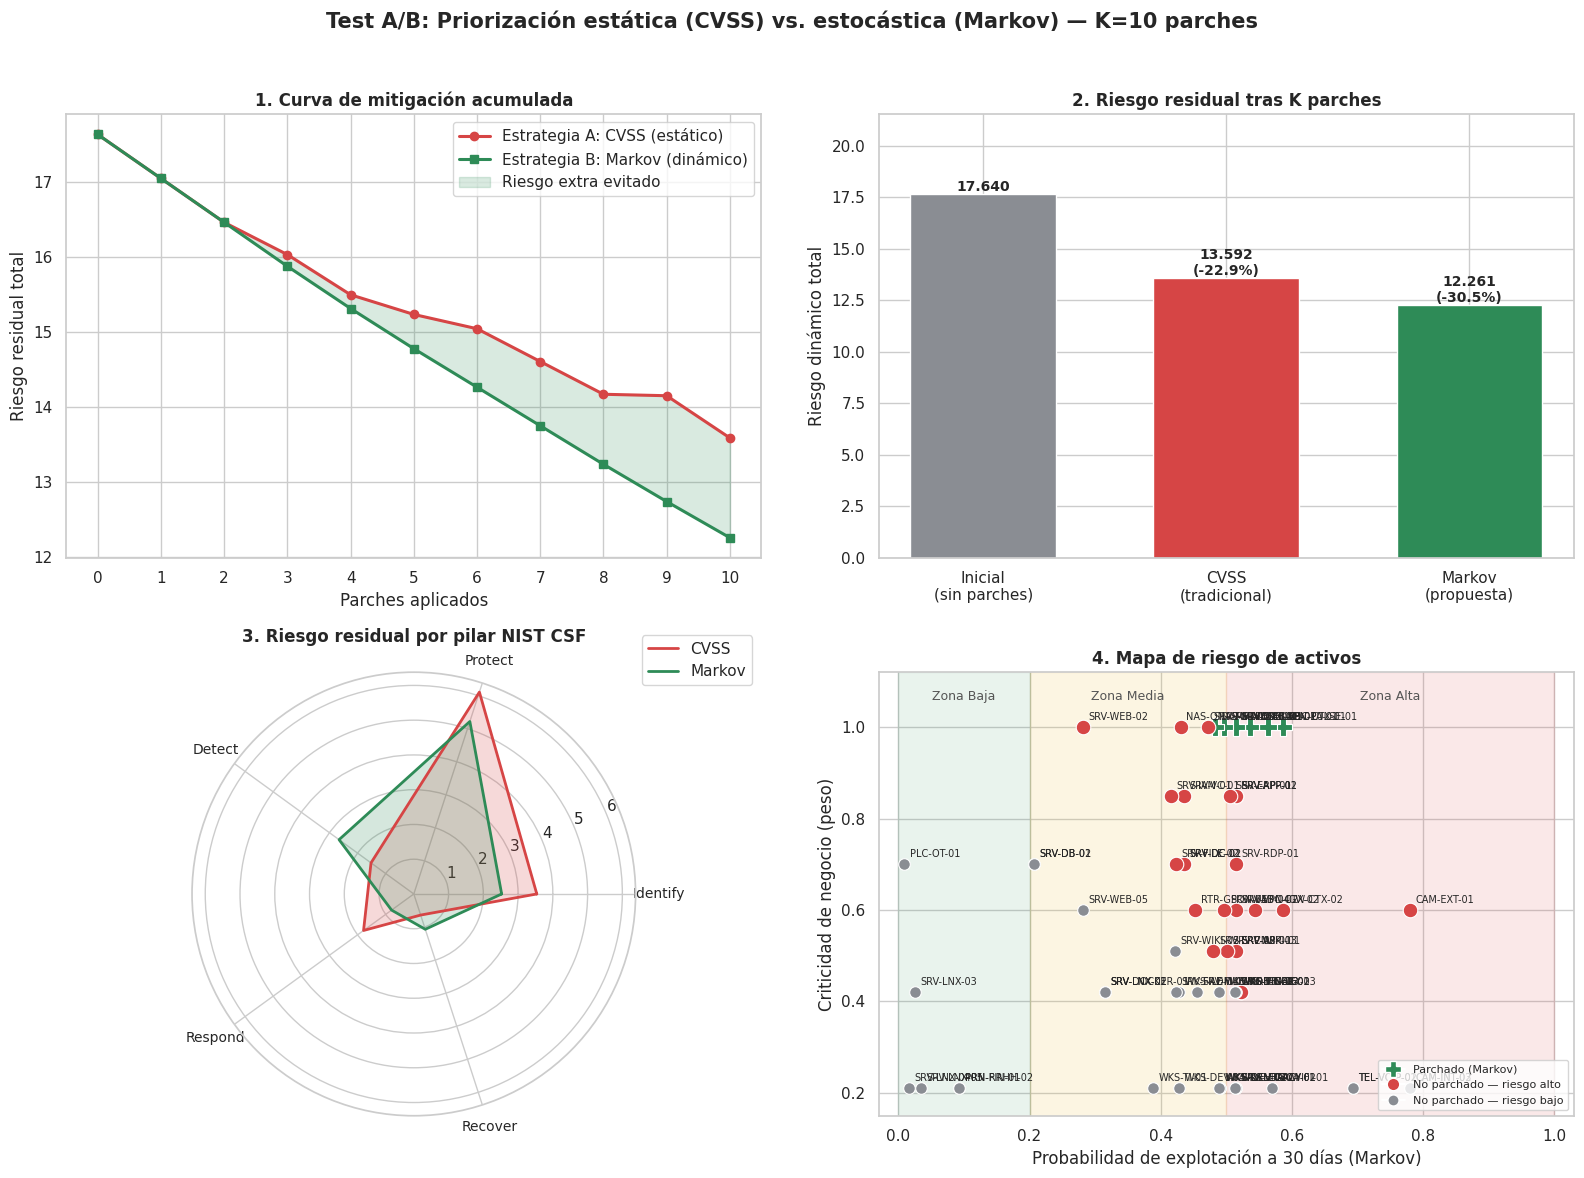


Parcheados por CVSS  : ['FW-EDGE-01', 'LB-F5-01', 'NAS-QNAP-01', 'PRN-FIN-01', 'SRV-APP-01', 'SRV-APP-02', 'SRV-APP-03', 'SRV-FILE-03', 'VPN-PA-01', 'VPN-PULSE-01']
Parcheados por Markov: ['ADC-CTX-01', 'FW-EDGE-01', 'LB-F5-01', 'SRV-MAIL-01', 'SRV-MAIL-02', 'SRV-VPN-01', 'SRV-WEB-01', 'SRV-WEB-03', 'VPN-PA-01', 'VPN-PULSE-01']
[OK] Evolución temporal guardada: evolucion_top5.png


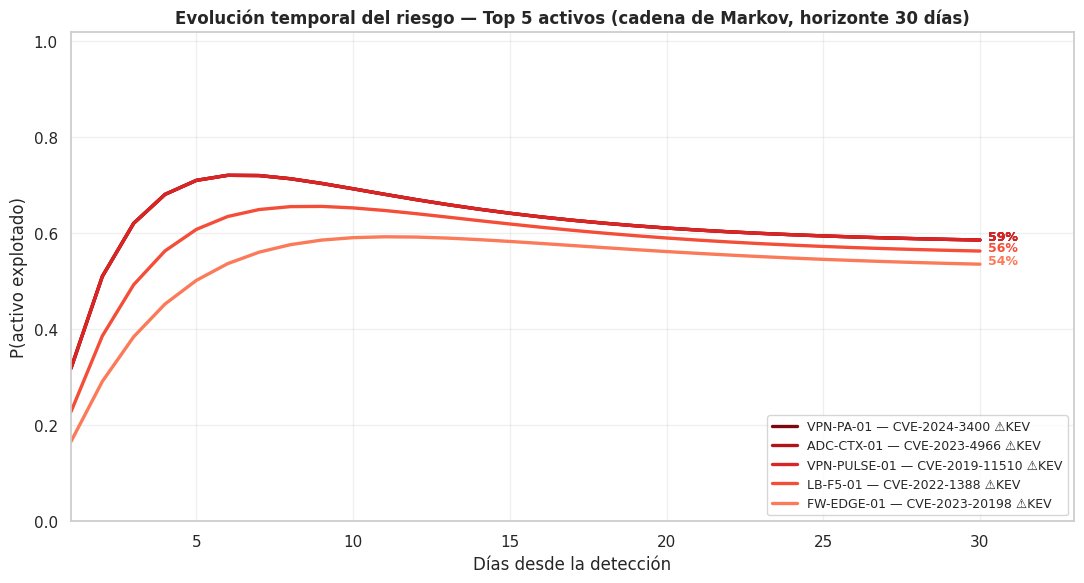

[INFO] Generando fichas vía LLM (gemini)...
[INFO] Generando análisis y conclusiones vía LLM (gemini)...
[OK] Reporte generado: reporte_mitigacion.md
[OK] Exportado: reporte_mitigacion.docx
[OK] Exportado: reporte_mitigacion.html
[OK] Ranking operativo exportado: ranking_priorizado.xlsx (68 activos)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# PIPELINE DE EJECUCIÓN (todo el análisis corre aquí)

# --- Parámetros del experimento ---
TTL_DIAS = 7            # vigencia de la base de conocimiento (días)
K_PARCHES = 10          # presupuesto de parcheo del ciclo
P_DETECCION = 0.1
P_MITIGACION = 0.05
HORIZONTE_DIAS = 30

# [2] Ingesta y validación (acepta .csv y .xlsx)
ingestor = DataIngestor(INVENTARIO)
df_inv = ingestor.cargar()

# [3] Enriquecimiento NVD + EPSS + KEV (con base de conocimiento local)
api = ThreatIntelAPI(nvd_api_key=NVD_API_KEY or None, ttl_dias=TTL_DIAS)
df_intel = api.enriquecer(ingestor.cves_unicos())

# [4] Modelo de Markov -> riesgo dinámico
df_full = df_inv.merge(df_intel, on="cve_id", how="left")
modelo = MarkovModel(p_d=P_DETECCION, p_m=P_MITIGACION, horizonte=HORIZONTE_DIAS)
df_riesgo = modelo.calcular_riesgos(df_full)

print("\n--- RANKING DE RIESGO DINÁMICO ---")
print(df_riesgo[["host", "cve_id", "criticidad", "cvss_score", "epss_score",
                 "prob_explotacion_30d", "riesgo_dinamico"]].to_string(index=False))

# [5] Test A/B + dashboard 2x2 + evolución temporal Top 5
dashboard = RiskDashboard()
resultados = dashboard.generar_test_ab(df_riesgo, k=K_PARCHES,
                                       save_path="dashboard_ab.png")
print("\nParcheados por CVSS  :", resultados["parcheados_cvss"])
print("Parcheados por Markov:", resultados["parcheados_markov"])
dashboard.grafico_evolucion(df_riesgo, modelo, top=5,
                            save_path="evolucion_top5.png")

# [6] Informe ejecutivo (LLM o plantillas locales) + exportación y descarga
reporter = ReportGenerator()
reporte = reporter.generar(df_riesgo, resultados, k=K_PARCHES)
reporter.exportar(("docx", "html"))                    # MD -> DOCX + HTML
reporter.exportar_ranking_xlsx(df_riesgo, k=K_PARCHES) # planilla SecOps
reporter.archivos += ["dashboard_ab.png", "evolucion_top5.png"]
reporter.descargar_colab()            # en Colab descarga todos los entregables

[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).
[KEV] 9 activos elevados al piso EPSS 0.9 por explotación confirmada (CISA).

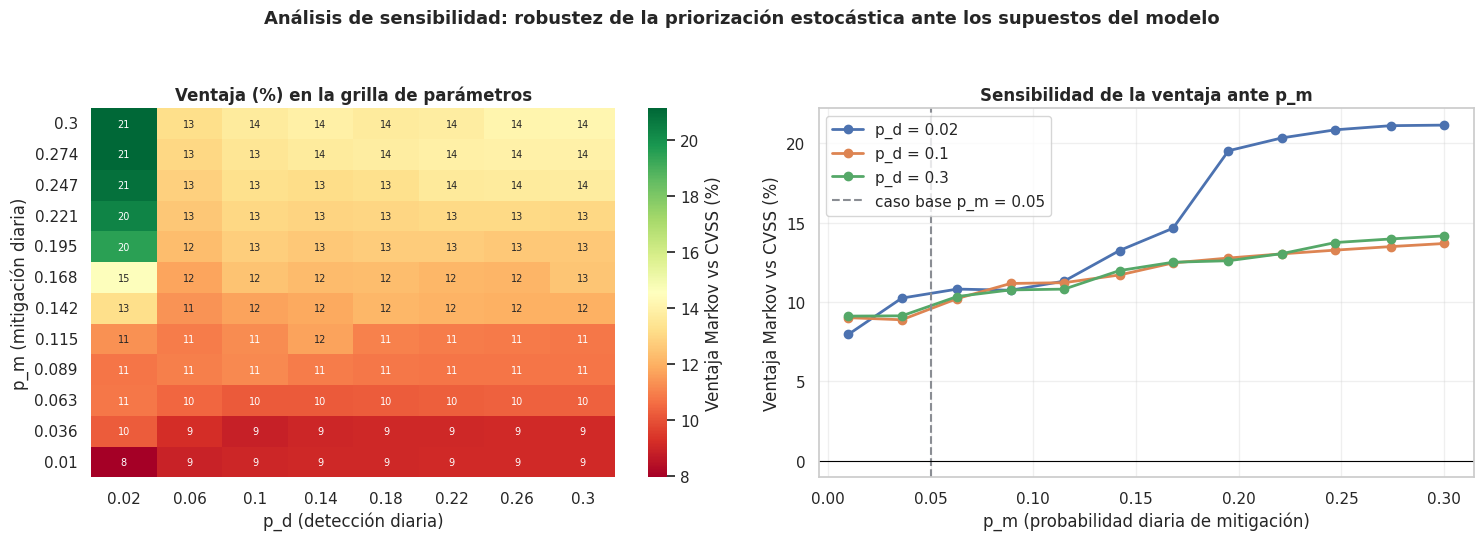

In [ ]:
# ANÁLISIS DE SENSIBILIDAD (robustez p_d/p_m)
# Pilar metodológico de la tesis: demuestra que la ventaja del modelo
# NO depende de los supuestos de parámetros (2-3 min de cómputo).

matriz_sensibilidad = SensitivityAnalysis(horizonte=HORIZONTE_DIAS).analizar(
    df_full, k=K_PARCHES, p_d_base=P_DETECCION, p_m_base=P_MITIGACION,
    save_path="sensibilidad.png")

In [ ]:
# ANÁLISIS DE DIVERGENCIA (valor agregado del modelo)
# Identifica los activos donde las estrategias difieren: la ventaja %
# proviene exactamente de estos activos que Markov priorizó y CVSS ignoró.

set_cvss = set(resultados["parcheados_cvss"])
set_markov = set(resultados["parcheados_markov"])
solo_markov = set_markov - set_cvss
solo_cvss = set_cvss - set_markov
print(f"[VALOR AGREGADO] Activos que Markov PRIORIZÓ y CVSS ignoró: {solo_markov}")
print(f"[CONTRASTE] Activos que CVSS eligió pero Markov consideró de menor riesgo: {solo_cvss}")
print("\nDetalle de activos salvados por la estrategia estocástica:")
cols_div = ["host", "software", "cvss_score", "epss_score",
            "riesgo_dinamico", "criticidad"]
print(df_riesgo[df_riesgo["host"].isin(solo_markov)][cols_div].to_string(index=False))
print("\nActivos priorizados por CVSS con menor riesgo real:")
print(df_riesgo[df_riesgo["host"].isin(solo_cvss)][cols_div].to_string(index=False))


[VALOR AGREGADO] Activos que Markov PRIORIZÓ y CVSS ignoró: {'ADC-CTX-01', 'SRV-MAIL-02', 'SRV-VPN-01', 'SRV-MAIL-01', 'SRV-WEB-01', 'SRV-WEB-03'}
[CONTRASTE] Activos que CVSS eligió pero Markov consideró de menor riesgo: {'NAS-QNAP-01', 'SRV-APP-03', 'SRV-FILE-03', 'PRN-FIN-01', 'SRV-APP-02', 'SRV-APP-01'}

Detalle de activos salvados por la estrategia estocástica:
       host             software  cvss_score  epss_score  riesgo_dinamico criticidad
 ADC-CTX-01 Citrix NetScaler ADC         9.4     0.99999         0.586104       Alta
 SRV-VPN-01     Fortinet FortiOS         9.1     0.99999         0.514182       Alta
SRV-MAIL-01   Microsoft Exchange         9.1     0.99999         0.514182       Alta
 SRV-WEB-03        Apache Struts         9.8     0.99999         0.514182       Alta
 SRV-WEB-01   Apache HTTP Server         9.8     0.99992         0.497076       Alta
SRV-MAIL-02   Microsoft Exchange         8.0     0.99970         0.482568       Alta

Activos priorizados por CVSS con me